<p style="font-family: Times New Roman;">Домашняя работа №4. Выполнил: Сафаров Нурлан. ИИТММ. Программная инженерия. Магистратура. 1 курс. 3825М1ПР1.</p>

<p style="font-family: Times New Roman;"><b>Пункт №0.</b> Описание задачи.</p>

<p style="font-family: Times New Roman;">Данные об оттоке абонентов телекоммуникационной компании содержат информацию о вымышленной телекоммуникационной компании, которая предоставляла услуги домашней телефонной связи и Интернета 7043 абонентам в Калифорнии в третьем квартале. В них указано, какие клиенты ушли, остались или подписались на их услуги. Была, впрочем-то, поставлена задача бинарной классификации: предсказать, какие клиенты телеком-компании уйдут, а какие — останутся.</p>

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<p style="font-family: Times New Roman;"><b>Пункт №1.</b> Чтение данных.</p>

In [48]:
data = pd.read_csv('C:/Users/Нурлан Сафаров/Documents/telco.csv')
data

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,Female,30,No,No,No,No,0,United States,California,...,0,1639.44,3039.53,5,Stayed,No,45,5306,NaN,NaN
7039,6840-RESVB,Male,38,No,No,Yes,Yes,2,United States,California,...,0,865.20,2807.47,3,Stayed,No,59,2140,NaN,NaN
7040,2234-XADUH,Female,30,No,No,Yes,Yes,2,United States,California,...,0,2135.52,9453.04,4,Stayed,No,71,5560,NaN,NaN
7041,4801-JZAZL,Female,32,No,No,Yes,Yes,2,United States,California,...,0,0.00,319.21,4,Stayed,No,59,2793,NaN,NaN


<p style="font-family: Times New Roman;">Более подробно познакомимся с колонками (признаками):</p>

In [49]:
data.columns

Index(['Customer ID', 'Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married',
       'Dependents', 'Number of Dependents', 'Country', 'State', 'City',
       'Zip Code', 'Latitude', 'Longitude', 'Population', 'Quarter',
       'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer',
       'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Satisfaction Score', 'Customer Status', 'Churn Label',
       'Churn Score', 'CLTV', 'Churn Category', 'Churn Reason'],
      dtype='object')


<p style="font-family: Times New Roman;">50 признаков:</p>

<p style="font-family: Times New Roman;">
1. <strong>Customer ID</strong> — уникальный идентификатор клиента<br>
2. <strong>Gender</strong> — пол клиента<br>
3. <strong>Age</strong> — текущий возраст клиента в годах<br>
4. <strong>Under 30</strong> — указывает, клиенту меньше 30 лет<br>
5. <strong>Senior Citizen</strong> — указывает, клиенту 65 лет или старше<br>
6. <strong>Married</strong> — в браке ли клиент<br>
7. <strong>Dependents</strong> — проживает ли клиент с иждивенцами<br>
8. <strong>Number of Dependents</strong> — количество иждивенцев, проживающих с клиентом<br>
9. <strong>Country</strong> — страна основного места жительства клиента<br>
10. <strong>State</strong> — штат основного места жительства клиента<br>
11. <strong>City</strong> — город основного места жительства клиента<br>
12. <strong>Zip Code</strong> — почтовый индекс основного места жительства клиента<br>
13. <strong>Latitude</strong> — широта основного места жительства клиента<br>
14. <strong>Longitude</strong> — долгота основного места жительства клиента<br>
15. <strong>Population</strong> — оценка численности населения для области почтового индекса<br>
16. <strong>Quarter</strong> — финансовый квартал, из которого получены данные<br>
17. <strong>Referred a Friend</strong> — рекомендовал ли клиент друга или члена семьи<br>
18. <strong>Number of Referrals</strong> — количество рекомендаций, сделанных клиентом<br>
19. <strong>Tenure in Months</strong> — общее количество месяцев пользования услугами компании<br>
20. <strong>Offer</strong> — последнее маркетинговое предложение, которое принял клиент<br>
21. <strong>Phone Service</strong> — подписан ли клиент на услугу домашнего телефона<br>
22. <strong>Avg Monthly Long Distance Charges</strong> — средние расходы на междугородние звонки<br>
23. <strong>Multiple Lines</strong> — подписан ли клиент на несколько телефонных линий<br>
24. <strong>Internet Service</strong> — подписан ли клиент на интернет-услуги<br>
25. <strong>Internet Type</strong> — тип интернет соединения<br>
26. <strong>Avg Monthly GB Download</strong> — средний объем загрузки в гигабайтах<br>
27. <strong>Online Security</strong> — подписан ли на дополнительную услугу онлайн-безопасности<br>
28. <strong>Online Backup</strong> — подписан ли на услугу онлайн-резервного копирования<br>
29. <strong>Device Protection Plan</strong> — подписан ли на план защиты устройств<br>
30. <strong>Premium Tech Support</strong> — подписан ли на план технической поддержки<br>
31. <strong>Streaming TV</strong> — использует ли интернет для потокового ТВ<br>
32. <strong>Streaming Movies</strong> — использует ли интернет для потоковых фильмов<br>
33. <strong>Streaming Music</strong> — использует ли интернет для потоковой музыки<br>
34. <strong>Unlimited Data</strong> — платит ли за неограниченную загрузку (или выгрузку) данных<br>
35. <strong>Contract</strong> — текущий тип контракта клиента<br>
36. <strong>Paperless Billing</strong> — выбрал ли безбумажный счет<br>
37. <strong>Payment Method</strong> — метод оплаты счета<br>
38. <strong>Monthly Charge</strong> — текущая общая ежемесячная плата за все услуги<br>
39. <strong>Total Charges</strong> — общая сумма расходов клиента<br>
40. <strong>Total Refunds</strong> — общая сумма возвратов клиента<br>
41. <strong>Total Extra Data Charges</strong> — общие расходы на дополнительные загрузки данных<br>
42. <strong>Total Long Distance Charges</strong> — общие расходы на междугородние звонки<br>
43. <strong>Total Revenue</strong> — общая сумма оплат<br>
44. <strong>Satisfaction Score</strong> — оценка удовлетворенности клиента от 1 до 5<br>
45. <strong>Customer Status</strong> — статус клиента на конец квартала<br>
46. <strong>Churn Label</strong> — метка оттока (Yes/No)<br>
47. <strong>Churn Score</strong> — оценка вероятности оттока от 0 до 100<br>
48. <strong>CLTV</strong> — ценность клиента<br>
49. <strong>Churn Category</strong> — категория высокого уровня для причины оттока<br>
50. <strong>Churn Reason</strong> — конкретная причина ухода клиента из компании
</p>

<p style="font-family: Times New Roman;"><b>Пункт №3.</b> Визуализация данных и вычисление основных характеристик.</p>

In [50]:
describe_one = data.describe(include = 'all')
describe_one

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
count,7043,7043,7043.000000,7043,7043,7043,7043,7043.000000,7043,7043,...,7043.000000,7043.000000,7043.000000,7043.000000,7043,7043,7043.000000,7043.000000,1869,1869
unique,7043,2,NaN,2,2,2,2,NaN,1,1,...,NaN,NaN,NaN,NaN,3,2,NaN,NaN,5,20
top,8779-QRDMV,Male,NaN,No,No,No,No,NaN,United States,California,...,NaN,NaN,NaN,NaN,Stayed,No,NaN,NaN,Competitor,Competitor had better devices
freq,1,3555,NaN,5642,5901,3641,5416,NaN,7043,7043,...,NaN,NaN,NaN,NaN,4720,5174,NaN,NaN,841,313
mean,NaN,NaN,46.509726,NaN,NaN,NaN,NaN,0.468692,NaN,NaN,...,6.860713,749.099262,3034.379056,3.244924,NaN,NaN,58.505040,4400.295755,NaN,NaN
std,NaN,NaN,16.750352,NaN,NaN,NaN,NaN,0.962802,NaN,NaN,...,25.104978,846.660055,2865.204542,1.201657,NaN,NaN,21.170031,1183.057152,NaN,NaN
min,NaN,NaN,19.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,...,0.000000,0.000000,21.360000,1.000000,NaN,NaN,5.000000,2003.000000,NaN,NaN
25%,NaN,NaN,32.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,...,0.000000,70.545000,605.610000,3.000000,NaN,NaN,40.000000,3469.000000,NaN,NaN
50%,NaN,NaN,46.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,...,0.000000,401.440000,2108.640000,3.000000,NaN,NaN,61.000000,4527.000000,NaN,NaN
75%,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,...,0.000000,1191.100000,4801.145000,4.000000,NaN,NaN,75.500000,5380.500000,NaN,NaN


<p style="font-family: Times New Roman;">Как ни странно, получили следующие статистики:</p>

<p style="font-family: Times New Roman;">
1. <strong>count</strong> — количество непустых значений<br>
2. <strong>unique</strong> — количество уникальных значений<br>
3. <strong>top</strong> — самое частое значение (мода)<br>
4. <strong>fraq</strong> — частота самого частого значения<br>
5. <strong>mean</strong> — среднее арифметическое<br>
6. <strong>std</strong> — стандартное отклонение (мера разброса)<br>
7. <strong>min/max</strong> — диапазон значений<br>
8. <strong>25%/50%/75%</strong> — квартили<br>
</p>

<p style="font-family: Times New Roman;">Выясним, какие признаки являются категориальными, а какие — количественными, и посчитаем их количество:</p>

In [51]:
categorical_columns = [c for c in data.columns if data[c].dtype.name == 'object']
numerical_columns   = [c for c in data.columns if data[c].dtype.name != 'object']
print(f'Категориальные признаки (количество): {len(categorical_columns)}')
print(f'Категориальные признаки: {categorical_columns}')
print('\n')
print(f'Количественные признаки (количество): {len(numerical_columns)}')
print(f'Количественные признаки: {numerical_columns}')

Категориальные признаки (количество): 31
Категориальные признаки: ['Customer ID', 'Gender', 'Under 30', 'Senior Citizen', 'Married', 'Dependents', 'Country', 'State', 'City', 'Quarter', 'Referred a Friend', 'Offer', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Customer Status', 'Churn Label', 'Churn Category', 'Churn Reason']


Количественные признаки (количество): 19
Количественные признаки: ['Age', 'Number of Dependents', 'Zip Code', 'Latitude', 'Longitude', 'Population', 'Number of Referrals', 'Tenure in Months', 'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Satisfaction Score', 'Churn Score', 'CLTV']


<p style="font-family: Times New Roman;">Большое количество признаков. Построим корреляционную матрицу для выявления возможной зависимости между переменными. При обнаружении сильной зависимости между ними — построим для них матрицу рассеивания.</p>

In [52]:
data_corr = data.corr(numeric_only=True)
data_corr

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Population,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Churn Score,CLTV
Age,1.000000,-0.119000,-0.008183,-0.010305,0.007612,-0.018881,-0.025141,0.009927,-0.011749,-0.376595,0.144685,0.059684,0.024168,0.025036,0.003065,0.048265,-0.085170,0.083919,-0.001826
Number of Dependents,-0.119000,1.000000,0.016493,0.029081,-0.024271,-0.015486,0.278003,0.108237,-0.007324,0.129966,-0.131837,0.022535,0.014023,-0.014436,0.068966,0.038038,0.152873,-0.160743,0.049611
Zip Code,-0.008183,0.016493,1.000000,0.894769,-0.790564,-0.424067,0.001463,0.007146,0.005894,-0.010998,-0.010775,0.001978,-0.003797,-0.014550,0.005063,0.002944,0.002121,-0.018020,-0.003207
Latitude,-0.010305,0.029081,0.894769,1.000000,-0.885979,-0.434801,0.018715,0.011963,0.002631,-0.027676,-0.030325,-0.002784,-0.009901,-0.013233,0.008029,0.000082,0.022367,-0.037615,0.000214
Longitude,0.007612,-0.024271,-0.790564,-0.885979,1.000000,0.296288,-0.009893,-0.009672,-0.004341,0.030979,0.028429,0.003811,-0.000597,0.010461,-0.006923,0.001062,-0.009048,0.019394,-0.000513
Population,-0.018881,-0.015486,-0.424067,-0.434801,0.296288,1.000000,-0.007704,-0.012102,-0.018665,0.024759,0.009597,-0.006434,0.019627,0.012031,-0.018640,-0.010546,-0.031056,0.020012,-0.000648
Number of Referrals,-0.025141,0.278003,0.001463,0.018715,-0.009893,-0.007704,1.000000,0.326975,0.006336,0.038575,0.028173,0.250378,0.024756,0.000350,0.216190,0.261853,0.188926,-0.202209,0.122843
Tenure in Months,0.009927,0.108237,0.007146,0.011963,-0.009672,-0.012102,0.326975,1.000000,0.014596,0.049119,0.247582,0.826074,0.059021,0.082266,0.674149,0.853146,0.210557,-0.224982,0.396292
Avg Monthly Long Distance Charges,-0.011749,-0.007324,0.005894,0.002631,-0.004341,-0.018665,0.006336,0.014596,1.000000,-0.030455,0.138396,0.069500,-0.018644,0.002414,0.599828,0.232291,0.001146,0.021857,0.023858
Avg Monthly GB Download,-0.376595,0.129966,-0.010998,-0.027676,0.030979,0.024759,0.038575,0.049119,-0.030455,1.000000,0.391787,0.223268,0.002397,0.088939,0.011373,0.180726,-0.091657,0.022421,0.023043


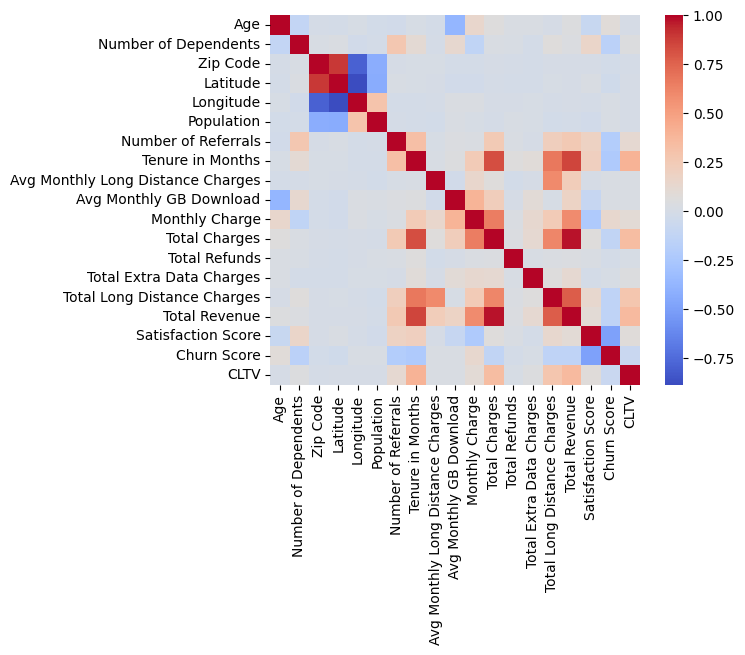

In [53]:
sns.heatmap(data_corr, square=True, cmap='coolwarm')
pass

In [54]:
data_corr.where(np.triu(data_corr > 0.5, k=1)).stack().sort_values(ascending=False)

Total Charges                      Total Revenue                  0.972212
Zip Code                           Latitude                       0.894769
Tenure in Months                   Total Revenue                  0.853146
                                   Total Charges                  0.826074
Total Long Distance Charges        Total Revenue                  0.778559
Tenure in Months                   Total Long Distance Charges    0.674149
Monthly Charge                     Total Charges                  0.651236
Total Charges                      Total Long Distance Charges    0.610185
Avg Monthly Long Distance Charges  Total Long Distance Charges    0.599828
Monthly Charge                     Total Revenue                  0.588887
dtype: float64

<p style="font-family: Times New Roman;">Заметим, что чем больше месяцев клиент пользуется услугами (Tenure in Months), тем выше его общие расходы (Total Revenue). Есть основания полагать, что они реже меняют поставщика услуг. Для детального изучения зависимости построим матрицу рассеивания для указанных переменных.</p>

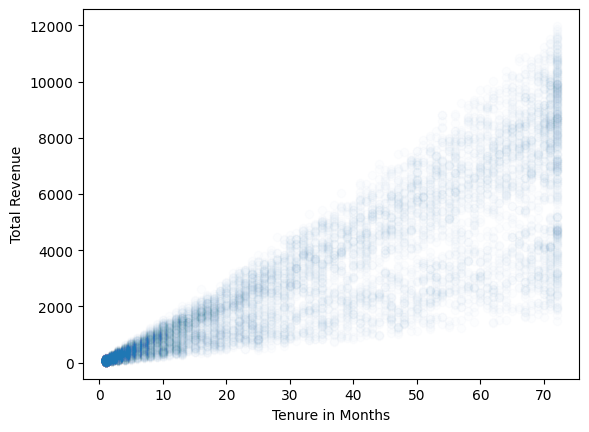

In [55]:
plt.scatter(data['Tenure in Months'], data['Total Revenue'], alpha=0.01)
plt.xlabel('Tenure in Months')
plt.ylabel('Total Revenue')
pass


<p style="font-family: Times New Roman;">Полная отрисовка неэффективна: точки перекрываются, а плотность не читается. В силу этого возьмём случайную выборку из 1000 наблюдений.</p>

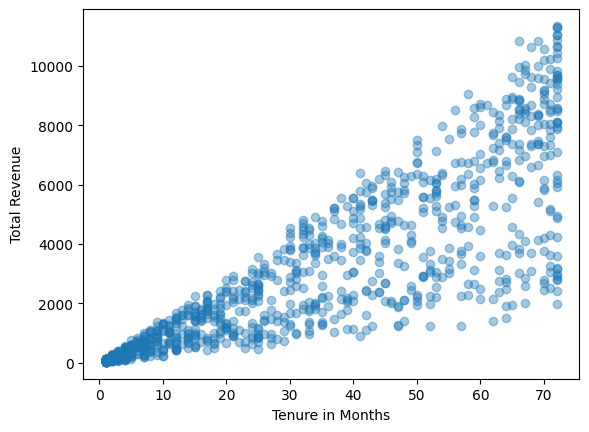

In [56]:
np.random.seed(20)
random_subset = np.random.choice(np.arange(data.shape[0]), size=1000, replace=False)
plt.scatter(data.iloc[random_subset]['Tenure in Months'], data.iloc[random_subset]['Total Revenue'], alpha=0.4)
plt.xlabel('Tenure in Months')
plt.ylabel('Total Revenue')
pass

<p style="font-family: Times New Roman;">Проверим, существует ли зависимость между возрастом (Age) и суммарными затратами (Total Revenue):</p>

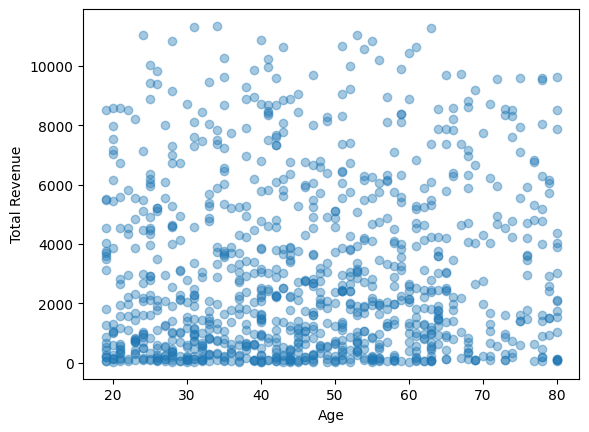

In [57]:
plt.scatter(data.iloc[random_subset]['Age'], data.iloc[random_subset]['Total Revenue'], alpha=0.4)
plt.xlabel('Age')
plt.ylabel('Total Revenue')
pass


<p style="font-family: Times New Roman;">Зависимость между ними не была обнаружена.</p>

<p style="font-family: Times New Roman;">Исключим из набора данных бесполезные столбцы и столбцы с дублирующей информацией:</p>

In [58]:
for column in data:
    print(column, data[column].unique())

Customer ID ['8779-QRDMV' '7495-OOKFY' '1658-BYGOY' ... '2234-XADUH' '4801-JZAZL'
 '3186-AJIEK']
Gender ['Male' 'Female']
Age [78 74 71 80 72 76 66 70 77 65 67 68 69 79 75 73 37 19 31 23 38 21 29 61
 27 20 56 51 48 32 34 41 30 26 62 64 45 53 63 42 24 54 39 43 50 22 40 47
 60 52 55 59 49 58 25 28 33 44 57 46 36 35]
Under 30 ['No' 'Yes']
Senior Citizen ['Yes' 'No']
Married ['No' 'Yes']
Dependents ['No' 'Yes']
Number of Dependents [0 1 3 2 5 4 6 7 8 9]
Country ['United States']
State ['California']
City ['Los Angeles' 'Inglewood' 'Whittier' ... 'Topaz' 'Jacumba' 'Holtville']
Zip Code [90022 90063 90065 ... 91934 92105 92250]
Latitude [34.02381  34.044271 34.108833 ... 32.649787 32.741859 32.811001]
Longitude [-118.156582 -118.185237 -118.229715 ... -116.2237   -117.090353
 -115.152865]
Population [68701 55668 47534 ...   116 73006  8062]
Quarter ['Q3']
Referred a Friend ['No' 'Yes']
Number of Referrals [ 0  1  6  2  4  3  7  5  8  9 10 11]
Tenure in Months [ 1  8 18 25 37 27 58 15  7 11  

<p style="font-family: Times New Roman;">Удаляем дублирующие, избыточные и константные признаки:</p>

In [59]:
columns_to_drop = [
    'Customer ID',           # излишняя информация
    'Under 30',              # дублируется в Age
    'Senior Citizen',        # дублируется в Age
    'Dependents',            # дублируется в Number of Dependents
    'Country', 'State',      # одно значение
    'City', 'Zip Code',      # излишняя информация
    'Latitude', 'Longitude', 'Population', # излишняя информация
    'Quarter',               # одно значение
    'Referred a Friend',     # дублируется в Number of Referrals
    'Customer Status',       # дублируется в Churn Label
    'Churn Score', 'Churn Category', 'Churn Reason', # пост-фактум
    'Tenure in Months', 'Total Charges' # высокая корреляция с Total Revenue
]

data = data.drop(columns=columns_to_drop)

<p style="font-family: Times New Roman;">Выведем обновленный датасет для проверки проведенных изменений:</p>

In [60]:
data

,Gender,Age,Married,Number of Dependents,Number of Referrals,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,...,Paperless Billing,Payment Method,Monthly Charge,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Churn Label,CLTV
0,Male,78,No,0,0,NaN,No,0.00,No,Yes,...,Yes,Bank Withdrawal,39.65,0.00,20,0.00,59.65,3,Yes,5433
1,Female,74,Yes,1,1,Offer E,Yes,48.85,Yes,Yes,...,Yes,Credit Card,80.65,0.00,0,390.80,1024.10,3,Yes,5302
2,Male,71,No,3,0,Offer D,Yes,11.33,Yes,Yes,...,Yes,Bank Withdrawal,95.45,45.61,0,203.94,1910.88,2,Yes,3179
3,Female,78,Yes,1,1,Offer C,Yes,19.76,No,Yes,...,Yes,Bank Withdrawal,98.50,13.43,0,494.00,2995.07,2,Yes,5337
4,Female,80,Yes,1,1,Offer C,Yes,6.33,Yes,Yes,...,Yes,Bank Withdrawal,76.50,0.00,0,234.21,3102.36,2,Yes,2793
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Female,30,No,0,0,NaN,Yes,22.77,No,No,...,Yes,Bank Withdrawal,21.15,19.31,0,1639.44,3039.53,5,No,5306
7039,Male,38,Yes,2,1,Offer C,Yes,36.05,Yes,Yes,...,Yes,Mailed Check,84.80,48.23,0,865.20,2807.47,3,No,2140
7040,Female,30,Yes,2,4,NaN,Yes,29.66,Yes,Yes,...,Yes,Credit Card,103.20,45.38,0,2135.52,9453.04,4,No,5560
7041,Female,32,Yes,2,1,NaN,No,0.00,No,Yes,...,Yes,Bank Withdrawal,29.60,27.24,0,0.00,319.21,4,No,2793


<p style="font-family: Times New Roman;"><b>Пункт №3.</b> Обработка пропущенных значений.</p>

<p style="font-family: Times New Roman;">Проверим наличие пропущенных значений:</p>

In [61]:
data.isna().sum() 

Gender                                  0
Age                                     0
Married                                 0
Number of Dependents                    0
Number of Referrals                     0
Offer                                3877
Phone Service                           0
Avg Monthly Long Distance Charges       0
Multiple Lines                          0
Internet Service                        0
Internet Type                        1526
Avg Monthly GB Download                 0
Online Security                         0
Online Backup                           0
Device Protection Plan                  0
Premium Tech Support                    0
Streaming TV                            0
Streaming Movies                        0
Streaming Music                         0
Unlimited Data                          0
Contract                                0
Paperless Billing                       0
Payment Method                          0
Monthly Charge                    

<p style="font-family: Times New Roman;">Обрабатываем два столбца с пропусками. Заметим, что признаки Offer и Internet Type — категориальные. Offer удаляем — в нём больше половины значений отсутствует. Internet Type заполняем значением "None" на основе логической связи с Internet Service (нет услуги — нет типа), после чего столбец Internet Service удаляем как ненужный.</p>

In [62]:
data['Internet Type'] = data['Internet Type'].fillna('No')
data = data.drop(columns=['Offer', 'Internet Service'])

<p style="font-family: Times New Roman;">Проверим текущее состояние данных после обработки, чтобы убедиться в готовности набора для дальнейшего анализа.</p>

In [63]:
data.isna().sum() 

Gender                               0
Age                                  0
Married                              0
Number of Dependents                 0
Number of Referrals                  0
Phone Service                        0
Avg Monthly Long Distance Charges    0
Multiple Lines                       0
Internet Type                        0
Avg Monthly GB Download              0
Online Security                      0
Online Backup                        0
Device Protection Plan               0
Premium Tech Support                 0
Streaming TV                         0
Streaming Movies                     0
Streaming Music                      0
Unlimited Data                       0
Contract                             0
Paperless Billing                    0
Payment Method                       0
Monthly Charge                       0
Total Refunds                        0
Total Extra Data Charges             0
Total Long Distance Charges          0
Total Revenue            

In [64]:
data['Internet Type'].unique()

array(['DSL', 'Fiber Optic', 'Cable', 'No'], dtype=object)

In [65]:
data

,Gender,Age,Married,Number of Dependents,Number of Referrals,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Type,Avg Monthly GB Download,...,Paperless Billing,Payment Method,Monthly Charge,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Churn Label,CLTV
0,Male,78,No,0,0,No,0.00,No,DSL,8,...,Yes,Bank Withdrawal,39.65,0.00,20,0.00,59.65,3,Yes,5433
1,Female,74,Yes,1,1,Yes,48.85,Yes,Fiber Optic,17,...,Yes,Credit Card,80.65,0.00,0,390.80,1024.10,3,Yes,5302
2,Male,71,No,3,0,Yes,11.33,Yes,Fiber Optic,52,...,Yes,Bank Withdrawal,95.45,45.61,0,203.94,1910.88,2,Yes,3179
3,Female,78,Yes,1,1,Yes,19.76,No,Fiber Optic,12,...,Yes,Bank Withdrawal,98.50,13.43,0,494.00,2995.07,2,Yes,5337
4,Female,80,Yes,1,1,Yes,6.33,Yes,Fiber Optic,14,...,Yes,Bank Withdrawal,76.50,0.00,0,234.21,3102.36,2,Yes,2793
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Female,30,No,0,0,Yes,22.77,No,No,0,...,Yes,Bank Withdrawal,21.15,19.31,0,1639.44,3039.53,5,No,5306
7039,Male,38,Yes,2,1,Yes,36.05,Yes,Cable,24,...,Yes,Mailed Check,84.80,48.23,0,865.20,2807.47,3,No,2140
7040,Female,30,Yes,2,4,Yes,29.66,Yes,Fiber Optic,59,...,Yes,Credit Card,103.20,45.38,0,2135.52,9453.04,4,No,5560
7041,Female,32,Yes,2,1,No,0.00,No,DSL,17,...,Yes,Bank Withdrawal,29.60,27.24,0,0.00,319.21,4,No,2793


<p style="font-family: Times New Roman;"><b>Пункт №4.</b> Обработка категориальных признаков.</p>

In [66]:
categorical_columns = [c for c in data.columns if data[c].dtype.name == 'object']
numerical_columns   = [c for c in data.columns if data[c].dtype.name != 'object']
print(f'Категориальные признаки (количество): {len(categorical_columns)}')
print(f'Категориальные признаки: {categorical_columns}')
print(f'Количественные признаки (количество): {len(numerical_columns)}')
print(f'Количественные признаки: {numerical_columns}')

Категориальные признаки (количество): 17
Категориальные признаки: ['Gender', 'Married', 'Phone Service', 'Multiple Lines', 'Internet Type', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Churn Label']
Количественные признаки (количество): 12
Количественные признаки: ['Age', 'Number of Dependents', 'Number of Referrals', 'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download', 'Monthly Charge', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue', 'Satisfaction Score', 'CLTV']


<p style="font-family: Times New Roman;">Перейдем к обработке категориальных признаков, предварительно разделив их на бинарные и небинарные:</p>

In [67]:
data_describe = data.describe(include = [object])
binary_columns    = [c for c in categorical_columns if data_describe[c]['unique'] == 2]
nonbinary_columns = [c for c in categorical_columns if data_describe[c]['unique'] > 2]
print(binary_columns, nonbinary_columns, sep='\n')

['Gender', 'Married', 'Phone Service', 'Multiple Lines', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Paperless Billing', 'Churn Label']
['Internet Type', 'Contract', 'Payment Method']


<p style="font-family: Times New Roman;">Обработаем бинарные категориальные признаки с помощью метода <b>Label Encoding</b> для приведения их к числовому формату:</p>

In [68]:
for i in binary_columns:
    data[i] = pd.factorize(data[i])[0]

In [69]:
data

,Gender,Age,Married,Number of Dependents,Number of Referrals,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Type,Avg Monthly GB Download,...,Paperless Billing,Payment Method,Monthly Charge,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Churn Label,CLTV
0,0,78,0,0,0,0,0.00,0,DSL,8,...,0,Bank Withdrawal,39.65,0.00,20,0.00,59.65,3,0,5433
1,1,74,1,1,1,1,48.85,1,Fiber Optic,17,...,0,Credit Card,80.65,0.00,0,390.80,1024.10,3,0,5302
2,0,71,0,3,0,1,11.33,1,Fiber Optic,52,...,0,Bank Withdrawal,95.45,45.61,0,203.94,1910.88,2,0,3179
3,1,78,1,1,1,1,19.76,0,Fiber Optic,12,...,0,Bank Withdrawal,98.50,13.43,0,494.00,2995.07,2,0,5337
4,1,80,1,1,1,1,6.33,1,Fiber Optic,14,...,0,Bank Withdrawal,76.50,0.00,0,234.21,3102.36,2,0,2793
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,30,0,0,0,1,22.77,0,No,0,...,0,Bank Withdrawal,21.15,19.31,0,1639.44,3039.53,5,1,5306
7039,0,38,1,2,1,1,36.05,1,Cable,24,...,0,Mailed Check,84.80,48.23,0,865.20,2807.47,3,1,2140
7040,1,30,1,2,4,1,29.66,1,Fiber Optic,59,...,0,Credit Card,103.20,45.38,0,2135.52,9453.04,4,1,5560
7041,1,32,1,2,1,0,0.00,0,DSL,17,...,0,Bank Withdrawal,29.60,27.24,0,0.00,319.21,4,1,2793


<p style="font-family: Times New Roman;">Для обработки небинарных категориальных признаков применим метод <b>One-Hot Encoding</b>, который преобразует каждую категорию в отдельный бинарный столбец, что позволяет избежать искусственного порядка между значениями:</p>

In [70]:
for c in nonbinary_columns:
    dummies_cl = pd.get_dummies(data[c], dtype=int)
    data = pd.concat((data, dummies_cl), axis=1)
    data = data.drop([c], axis=1)

In [71]:
data

,Gender,Age,Married,Number of Dependents,Number of Referrals,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Avg Monthly GB Download,Online Security,...,Cable,DSL,Fiber Optic,No,Month-to-Month,One Year,Two Year,Bank Withdrawal,Credit Card,Mailed Check
0,0,78,0,0,0,0,0.00,0,8,0,...,0,1,0,0,1,0,0,1,0,0
1,1,74,1,1,1,1,48.85,1,17,0,...,0,0,1,0,1,0,0,0,1,0
2,0,71,0,3,0,1,11.33,1,52,0,...,0,0,1,0,1,0,0,1,0,0
3,1,78,1,1,1,1,19.76,0,12,0,...,0,0,1,0,1,0,0,1,0,0
4,1,80,1,1,1,1,6.33,1,14,0,...,0,0,1,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,30,0,0,0,1,22.77,0,0,0,...,0,0,0,1,0,0,1,1,0,0
7039,0,38,1,2,1,1,36.05,1,24,1,...,1,0,0,0,0,1,0,0,0,1
7040,1,30,1,2,4,1,29.66,1,59,0,...,0,0,1,0,0,1,0,0,1,0
7041,1,32,1,2,1,0,0.00,0,17,1,...,0,1,0,0,1,0,0,1,0,0


<p style="font-family: Times New Roman;">Выполним проверку результатов преобразования, проанализировав количество категориальных признаков и выведя их список для подтверждения корректности обработки:</p>

In [72]:
categorical_columns = [c for c in data.columns if data[c].dtype.name == 'object']
print(f'Категориальные признаки (количество): {len(categorical_columns)}')
print(f'Категориальные признаки: {categorical_columns}')

Категориальные признаки (количество): 0
Категориальные признаки: []


<p style="font-family: Times New Roman;"><b>Пункт №5.</b> Нормализация количественных признаков.</p>

<p style="font-family: Times New Roman;">В результате преобразований все признаки стали количественными. Исходные числовые переменные сохранились без изменений, поэтому проведём их стандартизацию (Z-score normalization) для совместимости с закодированными категориальными признаками:</p>

In [73]:
for i in numerical_columns:
    data[i] = (data[i] - data[i].mean()) / data[i].std()

<p style="font-family: Times New Roman;">Получим, значит, следующие данные:</p>

In [74]:
data

,Gender,Age,Married,Number of Dependents,Number of Referrals,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Avg Monthly GB Download,Online Security,...,Cable,DSL,Fiber Optic,No,Month-to-Month,One Year,Two Year,Bank Withdrawal,Credit Card,Mailed Check
0,0,1.879977,0,-0.486800,-0.650362,0,-1.486198,0,-0.612931,0,...,0,1,0,0,1,0,0,1,0,0
1,1,1.641176,1,0.551835,-0.317162,1,1.676001,1,-0.172164,0,...,0,0,1,0,1,0,0,0,1,0
2,0,1.462075,0,2.629105,-0.650362,1,-0.752775,1,1.541931,0,...,0,0,1,0,1,0,0,1,0,0
3,1,1.879977,1,0.551835,-0.317162,1,-0.207077,0,-0.417035,0,...,0,0,1,0,1,0,0,1,0,0
4,1,1.999377,1,0.551835,-0.317162,1,-1.076439,1,-0.319086,0,...,0,0,1,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,-0.985635,0,-0.486800,-0.650362,1,-0.012231,0,-1.004724,0,...,0,0,0,1,0,0,1,1,0,0
7039,0,-0.508033,1,1.590470,-0.317162,1,0.847420,1,0.170655,1,...,1,0,0,0,0,1,0,0,0,1
7040,1,-0.985635,1,1.590470,0.682438,1,0.433778,1,1.884750,0,...,0,0,1,0,0,1,0,0,1,0
7041,1,-0.866234,1,1.590470,-0.317162,0,-1.486198,0,-0.172164,1,...,0,1,0,0,1,0,0,1,0,0


<p style="font-family: Times New Roman;">Выведем сводную статистическую информацию по данным, включая средние значения, стандартные отклонения, квартили и экстремальные значения для всех числовых признаков:</p>

In [75]:
data.describe()

,Gender,Age,Married,Number of Dependents,Number of Referrals,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Avg Monthly GB Download,Online Security,...,Cable,DSL,Fiber Optic,No,Month-to-Month,One Year,Two Year,Bank Withdrawal,Credit Card,Mailed Check
count,7043.000000,7.043000e+03,7043.000000,7.043000e+03,7.043000e+03,7043.000000,7.043000e+03,7043.000000,7.043000e+03,7043.000000,...,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.495244,6.456728e-17,0.483033,-1.614182e-17,-3.228364e-17,0.903166,-7.566478e-17,0.421837,7.263819e-17,0.286668,...,0.117848,0.234559,0.430924,0.216669,0.512566,0.220077,0.267358,0.555019,0.390317,0.054664
std,0.500013,1.000000e+00,0.499748,1.000000e+00,1.000000e+00,0.295752,1.000000e+00,0.493888,1.000000e+00,0.452237,...,0.322450,0.423753,0.495241,0.412004,0.499878,0.414328,0.442612,0.496999,0.487856,0.227340
min,0.000000,-1.642337e+00,0.000000,-4.868003e-01,-6.503624e-01,0.000000,-1.486198e+00,0.000000,-1.004724e+00,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,-8.662341e-01,0.000000,-4.868003e-01,-6.503624e-01,1.000000,-8.900086e-01,0.000000,-8.578019e-01,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,-3.043076e-02,0.000000,-4.868003e-01,-6.503624e-01,1.000000,-4.463559e-03,0.000000,-1.721639e-01,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,1.000000,8.053726e-01,1.000000,-4.868003e-01,3.492380e-01,1.000000,8.697532e-01,1.000000,3.175774e-01,1.000000,...,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000
max,1.000000,1.999377e+00,1.000000,8.860916e+00,3.014839e+00,1.000000,1.749796e+00,1.000000,3.158077e+00,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


<p style="font-family: Times New Roman;"><b>Пункт №6.</b> Разбиение данных на обучающую и тестовую выборки.</p>

In [44]:
X = data.drop(['Churn Label'], axis=1)
y = data['Churn Label']

In [32]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=20)

<p style="font-family: Times New Roman;">Для предсказания целевой переменной задействуем полный набор входных признаков, исключив только саму целевую переменную. Разбили данные на обучающую и тестовую выборки в соотношении 70/30, чтобы обеспечить достаточный объём данных для обучения моделей и объективной оценки их качества.</p>

<p style="font-family: Times New Roman;"><b>Пункт №7.</b> Запуск метода K-ближайших соседей (kNN).</p>

<p style="font-family: Times New Roman;">Запустим алгоритм kNN с параметром k=7, выведя матрицу рассогласования и основные статистические показатели для оценки точности прогнозирования:</p>

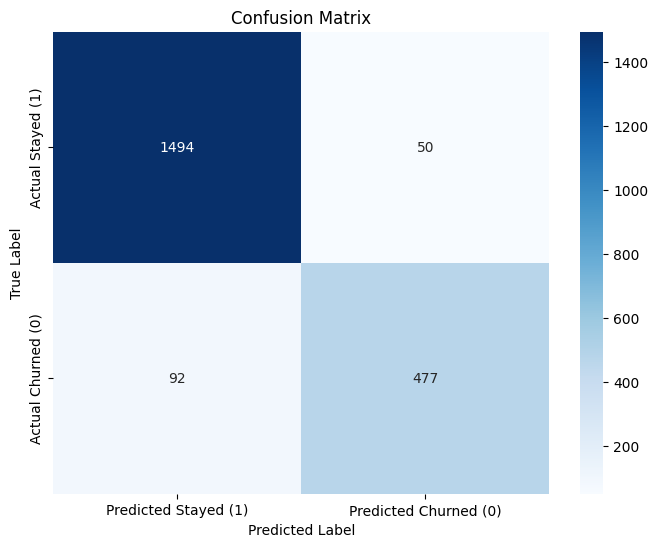

Результат классификации:
              precision    recall  f1-score   support

           0       0.91      0.84      0.87       569
           1       0.94      0.97      0.95      1544

    accuracy                           0.93      2113
   macro avg       0.92      0.90      0.91      2113
weighted avg       0.93      0.93      0.93      2113

Ошибка на обучающей выборке: 5.01%
Ошибка на тестовой выборке: 6.72%


In [33]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

model = KNeighborsClassifier(n_neighbors=7, p=2)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Матрица ошибок
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)

# Переворачиваем матрицу для того, чтобы она по структуре соответствовала общепринятой 
cm_flipped = cm[::-1, ::-1]

sns.heatmap(cm_flipped, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Stayed (1)', 'Predicted Churned (0)'],
            yticklabels=['Actual Stayed (1)', 'Actual Churned (0)'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print(f'Результат классификации:\n{classification_report(y_test, y_pred)}')
print(f'Ошибка на обучающей выборке: {round((1 - model.score(X_train, y_train)) * 100, 2)}%')
print(f'Ошибка на тестовой выборке: {round((1 - model.score(X_test, y_test)) * 100, 2)}%')

<p style="font-family: Times New Roman;"><b>Пункт №8.</b> Подбор оптимального значения гиперпараметра (количество ближайших соседей).</p>

<p style="font-family: Times New Roman;">Для повышения точности классификации выполним подбор оптимального значения параметра k:</p>

In [34]:
k_values = range(1, 101)
train_err = []
test_err = []
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k, p=2)
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    train_err.append(1 - model.score(X_train, y_train))
    test_err.append(1 - model.score(X_test, y_test))

<p style="font-family: Times New Roman;">Для визуализации зависимости качества модели от значения гиперпараметра построим график ошибки классификации в зависимости от количества ближайших соседей:</p>

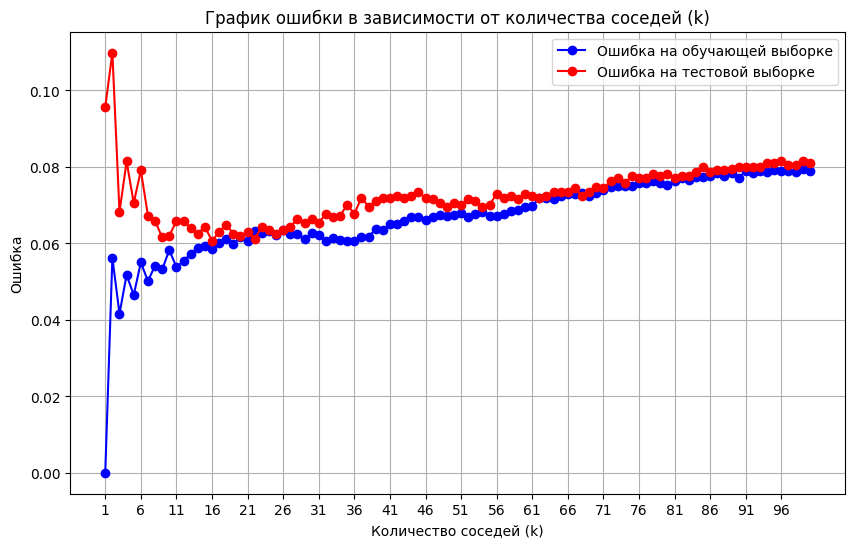

In [35]:
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_err, marker='o', color='blue', label='Ошибка на обучающей выборке')
plt.plot(k_values, test_err, marker='o', color='red', label='Ошибка на тестовой выборке')
plt.title('График ошибки в зависимости от количества соседей (k)')
plt.xlabel('Количество соседей (k)')
plt.ylabel('Ошибка')
plt.xticks(np.arange(1, 101, step=5))
plt.grid()
plt.legend()
plt.show()

<p style="font-family: Times New Roman;">Найдём оптимальное значение гиперпараметра (количество ближайших соседей):</p>

In [36]:
best_k = k_values[np.argmin(test_err)]
print(f'Оптимальное значение k: {best_k}')

Оптимальное значение k: 16


<p style="font-family: Times New Roman;"><b>Пункт №9.</b> Вычисление ошибок на обучающей и тестовой выборках. Вывод.</p>

In [37]:
print(f'Ошибка на обучающей выборке: {round(100 * train_err[test_err.index(min(test_err))], 2)}%')
print(f'Ошибка на тестовой выборке: {round(100 * min(test_err), 2)}%')

Ошибка на обучающей выборке: 5.84%
Ошибка на тестовой выборке: 6.06%


<p style="font-family: Times New Roman;">Оптимальным значением для алгоритма K-Nearest Neighbors с евклидовой метрикой (p=2) является k=16. Значения k < 16 свидетельствуют о излишней сложности модели и склонности к переобучению, тогда как при k > 16 наблюдается рост ошибки как на тестовой, так и на обучающей выборках, что указывает на чрезмерное упрощение модели и недообучение.</p>

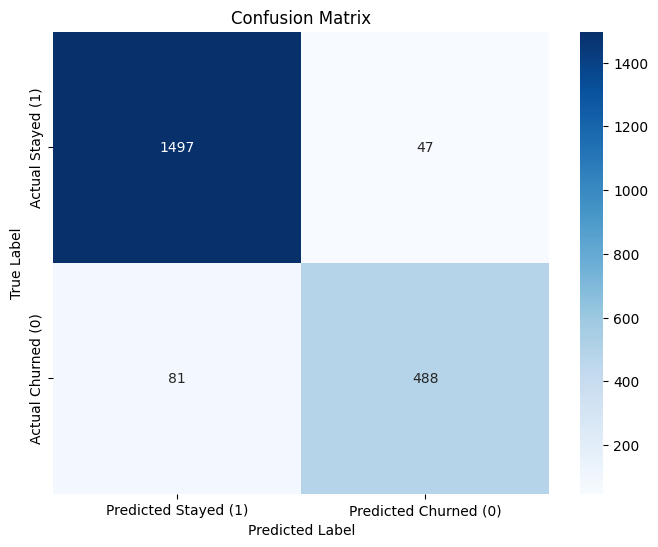

Результат классификации:
               precision    recall  f1-score   support

           0       0.91      0.86      0.88       569
           1       0.95      0.97      0.96      1544

    accuracy                           0.94      2113
   macro avg       0.93      0.91      0.92      2113
weighted avg       0.94      0.94      0.94      2113

Ошибка на обучающей выборке: 5.84%
Ошибка на тестовой выборке: 6.06%


In [38]:
from sklearn.metrics import classification_report, confusion_matrix

model = KNeighborsClassifier(n_neighbors=16, p=2)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Матрица ошибок
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)

# Переворачиваем матрицу для того, чтобы она по структуре соответствовала общепринятой
cm_flipped = cm[::-1, ::-1]

sns.heatmap(cm_flipped, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Stayed (1)', 'Predicted Churned (0)'],
            yticklabels=['Actual Stayed (1)', 'Actual Churned (0)'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print(f'Результат классификации:\n {classification_report(y_test, y_pred)}')
print(f'Ошибка на обучающей выборке: {round((1 - model.score(X_train, y_train)) * 100, 2)}%')
print(f'Ошибка на тестовой выборке: {round((1 - model.score(X_test, y_test)) * 100, 2)}%')

<p style="font-family: Times New Roman;"><b>Пункт №10.</b> Запуск других классификаторов и выбор их параметров. Сравнение результатов.</p>

<p style="font-family: Times New Roman;"><b>10.1.</b> Метод опорных векторов (SVC).</p>

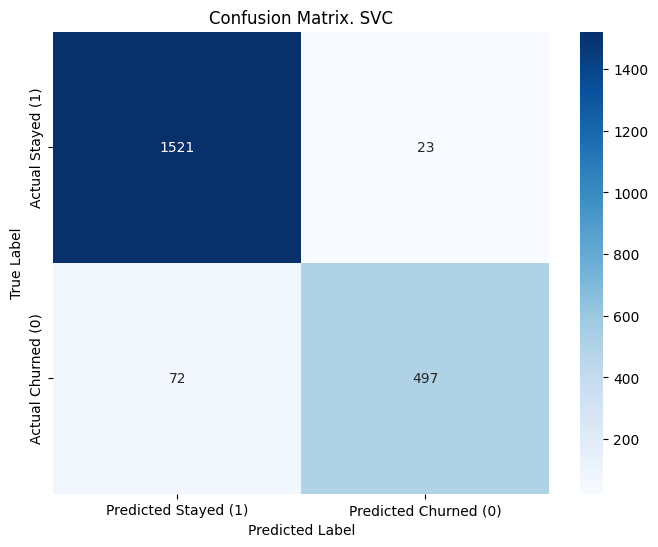

Результат классификации:
               precision    recall  f1-score   support

           0       0.96      0.87      0.91       569
           1       0.95      0.99      0.97      1544

    accuracy                           0.96      2113
   macro avg       0.96      0.93      0.94      2113
weighted avg       0.96      0.96      0.95      2113

Ошибка на обучающей выборке: 3.67%
Ошибка на тестовой выборке: 4.5%


In [39]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

svc = SVC(gamma='auto')
svc.fit(X_train, y_train)
y1_pred = svc.predict(X_test)
err_train = np.mean(y_train != svc.predict(X_train))
err_test  = np.mean(y_test  != svc.predict(X_test))

# Матрица ошибок
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y1_pred)

# Переворачиваем матрицу для того, чтобы она по структуре соответствовала общепринятой
cm_flipped = cm[::-1, ::-1]

sns.heatmap(cm_flipped, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Stayed (1)', 'Predicted Churned (0)'],
            yticklabels=['Actual Stayed (1)', 'Actual Churned (0)'])
plt.title('Confusion Matrix. SVC')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print(f'Результат классификации:\n {classification_report(y_test, y1_pred)}')
print(f'Ошибка на обучающей выборке: {round(100 * err_train, 2)}%')
print(f'Ошибка на тестовой выборке: {round(100 * err_test, 2)}%')

<p style="font-family: Times New Roman;">Подберём оптимальные значения параметров:</p>

In [40]:
from sklearn.model_selection import GridSearchCV
Cs = 10.**np.arange(-5, 5)
GammaS = 10.**np.arange(-5, 5)
svc = SVC(gamma='auto')
grid = GridSearchCV(svc, cv=3, param_grid = {'C': Cs, 'gamma': GammaS})
grid.fit(X_train, y_train)
best_C = grid.best_estimator_.C
best_gamma = grid.best_estimator_.gamma
print(f'Оптимальные параметры. C и gamma соответственно: {best_C}, {best_gamma}')

Оптимальные параметры. C и gamma соответственно: 10000.0, 0.001


<p style="font-family: Times New Roman;">Инициализируем SVC-классификатор с оптимальными параметрами, выполним обучение и проведём проверку качества классификации на тестовых данных:</p>

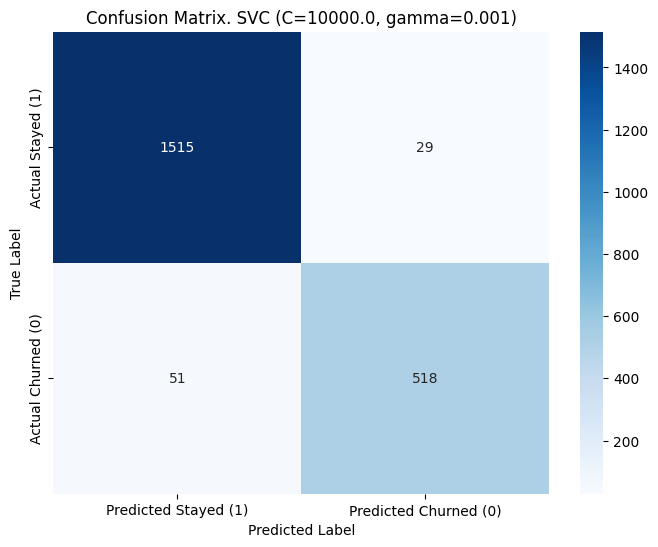

Результат классификации:
               precision    recall  f1-score   support

           0       0.95      0.91      0.93       569
           1       0.97      0.98      0.97      1544

    accuracy                           0.96      2113
   macro avg       0.96      0.95      0.95      2113
weighted avg       0.96      0.96      0.96      2113

Ошибка на обучающей выборке: 2.27%
Ошибка на тестовой выборке: 3.79%


In [41]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

svc = SVC(C=best_C, gamma=best_gamma).fit(X_train, y_train)
y1_pred = svc.predict(X_test)
err_train = np.mean(y_train != svc.predict(X_train))
err_test  = np.mean(y_test  != y1_pred)

# Матрица ошибок
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y1_pred)

# Переворачиваем матрицу для того, чтобы она по структуре соответствовала общепринятой
cm_flipped = cm[::-1, ::-1]

sns.heatmap(cm_flipped, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Stayed (1)', 'Predicted Churned (0)'],
            yticklabels=['Actual Stayed (1)', 'Actual Churned (0)'])
plt.title(f'Confusion Matrix. SVC (C={best_C}, gamma={best_gamma})')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print(f'Результат классификации:\n {classification_report(y_test, y1_pred)}')
print(f'Ошибка на обучающей выборке: {round(100 * err_train, 2)}%')
print(f'Ошибка на тестовой выборке: {round(100 * err_test, 2)}%')

<p style="font-family: Times New Roman;">Наблюдается преимущество метода опорных векторов перед алгоритмом K-ближайших соседей в данной задаче, что может быть связано со способностью метода опорных векторов эффективно работать в высокоразмерных пространствах и находить оптимальную разделяющую гиперплоскость.</p>

<p style="font-family: Times New Roman;"><b>10.2.</b> Градиентный бустинг (GBT).</p>

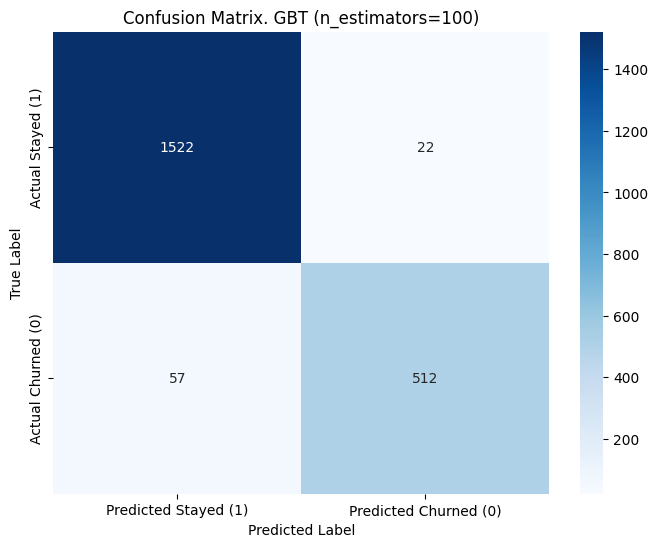

Результат классификации:
               precision    recall  f1-score   support

           0       0.96      0.90      0.93       569
           1       0.96      0.99      0.97      1544

    accuracy                           0.96      2113
   macro avg       0.96      0.94      0.95      2113
weighted avg       0.96      0.96      0.96      2113

Ошибка на обучающей выборке: 2.31%
Ошибка на тестовой выборке: 3.74%


In [42]:
from sklearn import ensemble
from sklearn.metrics import classification_report, confusion_matrix

gbt = ensemble.GradientBoostingClassifier(n_estimators=100)
gbt.fit(X_train, y_train)
y1_pred = gbt.predict(X_test)
err_train = np.mean(y_train != gbt.predict(X_train))
err_test = np.mean(y_test != y1_pred)

# Матрица ошибок 
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y1_pred)

# Переворачиваем матрицу для того, чтобы она по структуре соответствовала общепринятой
cm_flipped = cm[::-1, ::-1]

sns.heatmap(cm_flipped, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Stayed (1)', 'Predicted Churned (0)'],
            yticklabels=['Actual Stayed (1)', 'Actual Churned (0)'])
plt.title('Confusion Matrix. GBT (n_estimators=100)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print(f'Результат классификации:\n {classification_report(y_test, y1_pred)}')
print(f'Ошибка на обучающей выборке: {round(100 * err_train, 2)}%')
print(f'Ошибка на тестовой выборке: {round(100 * err_test, 2)}%')

<p style="font-family: Times New Roman;">Подберём оптимальные значения параметров:</p>

In [43]:
param_grid = {
    'learning_rate': [0.1, 0.01, 0.001],
    'max_depth': [3, 4],
    'min_samples_split': [2, 4],
    'min_samples_leaf': [1, 2]
}
gbt = ensemble.GradientBoostingClassifier(n_estimators = 100)
grid_search = GridSearchCV(gbt, param_grid=param_grid, cv=5)
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
print(f"Оптимальные параметры: {best_params}")

Оптимальные параметры: {'learning_rate': 0.1, 'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 2}


<p style="font-family: Times New Roman;">Инициализируем Gradient Boost Tree с оптимальными параметрами, выполним обучение и проведём проверку качества классификации на тестовых данных:</p>

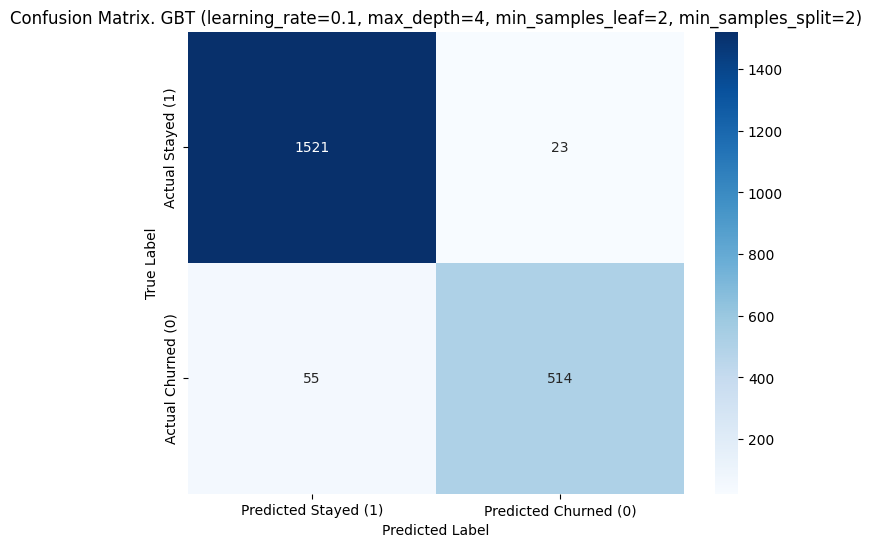

Результат классификации:
               precision    recall  f1-score   support

           0       0.96      0.90      0.93       569
           1       0.97      0.99      0.97      1544

    accuracy                           0.96      2113
   macro avg       0.96      0.94      0.95      2113
weighted avg       0.96      0.96      0.96      2113

Ошибка на обучающей выборке: 1.68%
Ошибка на тестовой выборке: 3.69%


In [44]:
from sklearn import ensemble
from sklearn.metrics import classification_report, confusion_matrix

gbt = ensemble.GradientBoostingClassifier(learning_rate=0.1, max_depth=4, min_samples_leaf=2, min_samples_split=2)
gbt.fit(X_train, y_train)
y1_pred = gbt.predict(X_test)
err_train = np.mean(y_train != gbt.predict(X_train))
err_test = np.mean(y_test != y1_pred)

# Матрица ошибок 
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y1_pred)

# Переворачиваем матрицу для того, чтобы она по структуре соответствовала общепринятой
cm_flipped = cm[::-1, ::-1]

sns.heatmap(cm_flipped, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Stayed (1)', 'Predicted Churned (0)'],
            yticklabels=['Actual Stayed (1)', 'Actual Churned (0)'])
plt.title('Confusion Matrix. GBT (learning_rate=0.1, max_depth=4, min_samples_leaf=2, min_samples_split=2)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print(f'Результат классификации:\n {classification_report(y_test, y1_pred)}')
print(f'Ошибка на обучающей выборке: {round(100 * err_train, 2)}%')
print(f'Ошибка на тестовой выборке: {round(100 * err_test, 2)}%')

<p style="font-family: Times New Roman;">Сравнительный анализ результатов показал, что градиентный бустинг (GBT) демонстрирует наивысшее качество прогнозирования, превосходя метод опорных векторов (SVC), который в свою очередь показывает более высокую эффективность по сравнению с алгоритмом K-ближайших соседей (kNN).</p>

<p style="font-family: Times New Roman;"><b>Пункт №11.</b> Борьба с несбалансированностью классов.</p>

<p style="font-family: Times New Roman;">Для решения проблемы несбалансированности классов доступны несколько ключевых подходов: ресемплирование данных (как увеличение миноритарного класса, так и уменьшение мажоритарного), взвешивание классов, генерация синтетических примеров, а также использование специализированных ансамблевых методов. Несмотря на то, что градиентный бустинг обладает встроенными механизмами работы с несбалансированными классами, дополнительно применим технику андерсэмплинга для балансировки классов и проведём сравнительный анализ поведения всех моделей в новых условиях.</p>

<p style="font-family: Times New Roman;">Посчитаем количество объектов в каждом классе и определим их процентное соотношение, чтобы точно оценить уровень несбалансированности данных:</p>

In [45]:
pct_churned = (y_train == 0).mean()    # Ушли (0)
pct_stayed = (y_train == 1).mean()     # Остались (1)

print(f"Распределение классов в обучающей выборке:")
print(f"Ушли (0): {pct_churned:.2%} ({int(pct_churned * len(y_train))} клиентов)")
print(f"Остались (1): {pct_stayed:.2%} ({int(pct_stayed * len(y_train))} клиентов)")
print(f"Всего клиентов: {len(y_train)}")
print(f"Соотношение: {pct_stayed/pct_churned:.1f}:1")

Распределение классов в обучающей выборке:
Ушли (0): 26.37% (1300 клиентов)
Остались (1): 73.63% (3630 клиентов)
Всего клиентов: 4930
Соотношение: 2.8:1


<p style="font-family: Times New Roman;">Как мной уже было сказано выше, проведём андерсэмплинг:</p>

In [46]:
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=20)
X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)

<p style="font-family: Times New Roman;">Посчитаем количество объектов в каждом классе и определим их процентное соотношение, чтобы посмотреть на результат проведения андерсэмплинга:</p>

In [47]:
pct_churned = (y_train_resampled == 0).mean()    # Ушли (0)
pct_stayed = (y_train_resampled == 1).mean()     # Остались (1)

print(f"Распределение классов в полученной выборке:")
print(f"Ушли (0): {pct_churned:.2%} ({int(pct_churned * len(y_train))} клиентов)")
print(f"Остались (1): {pct_stayed:.2%} ({int(pct_stayed * len(y_train))} клиентов)")
print(f"Всего клиентов: {len(y_train_resampled)}")
print(f"Соотношение: {pct_stayed/pct_churned:.1f}:1")

Распределение классов в полученной выборке:
Ушли (0): 50.00% (2465 клиентов)
Остались (1): 50.00% (2465 клиентов)
Всего клиентов: 2600
Соотношение: 1.0:1


<p style="font-family: Times New Roman;">После применения андерсэмплинга распределение классов в тренировочной выборке стало сбалансированным. Проведём обучение всех моделей на обновлённых тренировочных данных, сохраняя исходную тестовую выборку для объективной оценки эффективности методов.</p>

<p style="font-family: Times New Roman;"><b>11.1.</b> K-ближайших соседей.</p>

<p style="font-family: Times New Roman;">Подберём оптимальное значение гиперпараметра:</p>

In [48]:
k_values = range(1, 101)
train_err = []
test_err = []
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k, p=2)
    model.fit(X_train_resampled, y_train_resampled)
    y_train_pred = model.predict(X_train_resampled)
    y_test_pred = model.predict(X_test)
    train_err.append(1 - model.score(X_train_resampled, y_train_resampled))
    test_err.append(1 - model.score(X_test, y_test))

<p style="font-family: Times New Roman;">Для визуализации зависимости качества модели от значения гиперпараметра построим график ошибки классификации в зависимости от количества ближайших соседей:</p>

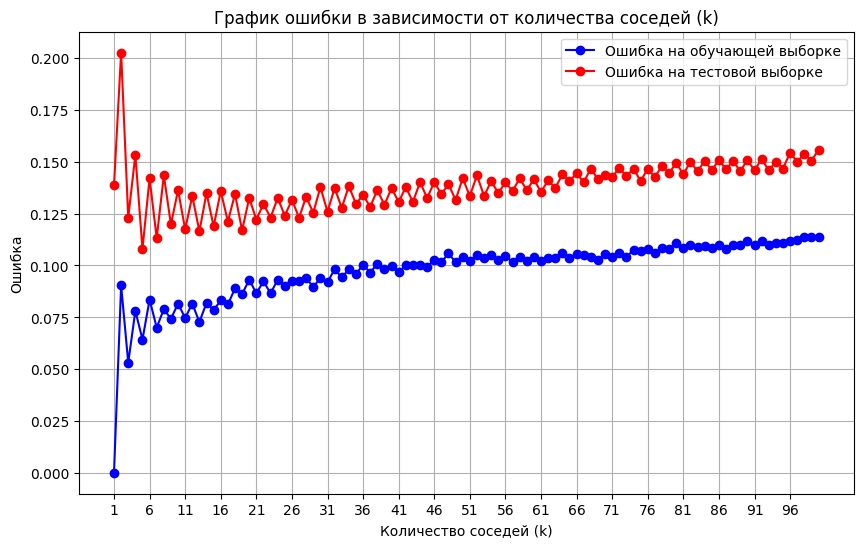

In [49]:
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_err, marker='o', color='blue', label='Ошибка на обучающей выборке')
plt.plot(k_values, test_err, marker='o', color='red', label='Ошибка на тестовой выборке')
plt.title('График ошибки в зависимости от количества соседей (k)')
plt.xlabel('Количество соседей (k)')
plt.ylabel('Ошибка')
plt.xticks(np.arange(1, 101, step=5))
plt.grid()
plt.legend()
plt.show()

<p style="font-family: Times New Roman;">Найдём оптимальное значение гиперпараметра (количество ближайших соседей) и ошибки на обучающей и тестовой выборках:</p>

In [50]:
best_k = k_values[np.argmin(test_err)]
print(f'Оптимальное значение k: {best_k}')
print(f'Ошибка на обучающей выборке: {round(100 * train_err[test_err.index(min(test_err))], 2)}%')
print(f'Ошибка на тестовой выборке: {round(100 * min(test_err), 2)}%')

Оптимальное значение k: 5
Ошибка на обучающей выборке: 6.42%
Ошибка на тестовой выборке: 10.79%


<p style="font-family: Times New Roman;">Протестируем модель с подобранным оптимальным гиперпараметром на тестовых данных:</p>

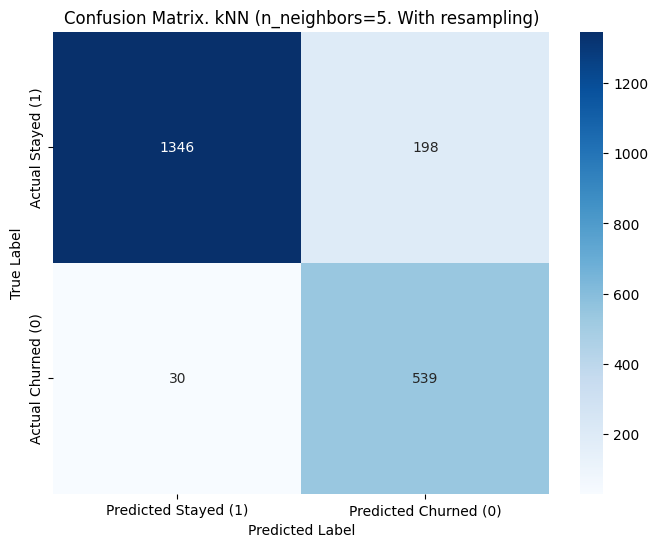

Результат классификации:
               precision    recall  f1-score   support

           0       0.73      0.95      0.83       569
           1       0.98      0.87      0.92      1544

    accuracy                           0.89      2113
   macro avg       0.85      0.91      0.87      2113
weighted avg       0.91      0.89      0.90      2113

Ошибка на обучающей выборке: 6.42%
Ошибка на тестовой выборке: 10.79%


In [51]:
from sklearn.metrics import classification_report, confusion_matrix

model = KNeighborsClassifier(n_neighbors=5, p=2)
model.fit(X_train_resampled, y_train_resampled)
y_pred = model.predict(X_test)

# Матрица ошибок
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)

# Переворачиваем матрицу для того, чтобы она по структуре соответствовала общепринятой
cm_flipped = cm[::-1, ::-1]

sns.heatmap(cm_flipped, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Stayed (1)', 'Predicted Churned (0)'],
            yticklabels=['Actual Stayed (1)', 'Actual Churned (0)'])
plt.title('Confusion Matrix. kNN (n_neighbors=5. With resampling)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print(f'Результат классификации:\n {classification_report(y_test, y_pred)}')
print(f'Ошибка на обучающей выборке: {round((1 - model.score(X_train_resampled, y_train_resampled)) * 100, 2)}%')
print(f'Ошибка на тестовой выборке: {round((1 - model.score(X_test, y_test)) * 100, 2)}%')

<p style="font-family: Times New Roman;"><b>11.2.</b> Метод опорных векторов.</p>

<p style="font-family: Times New Roman;">Подберём оптимальные значения параметров:</p>

In [52]:
Cs = 10.**np.arange(-5, 5)
GammaS = 10.**np.arange(-5, 5)
svc = SVC(gamma='auto')
grid = GridSearchCV(svc, cv=3, param_grid = {'C': Cs, 'gamma': GammaS})
grid.fit(X_train_resampled, y_train_resampled)
best_C = grid.best_estimator_.C
best_gamma = grid.best_estimator_.gamma
print(f'Оптимальные параметры. C и gamma соответственно: {best_C}, {best_gamma}')

Оптимальные параметры. C и gamma соответственно: 10.0, 0.01


<p style="font-family: Times New Roman;">Протестируем модель с подобранными оптимальными параметрами на тестовых данных:</p>

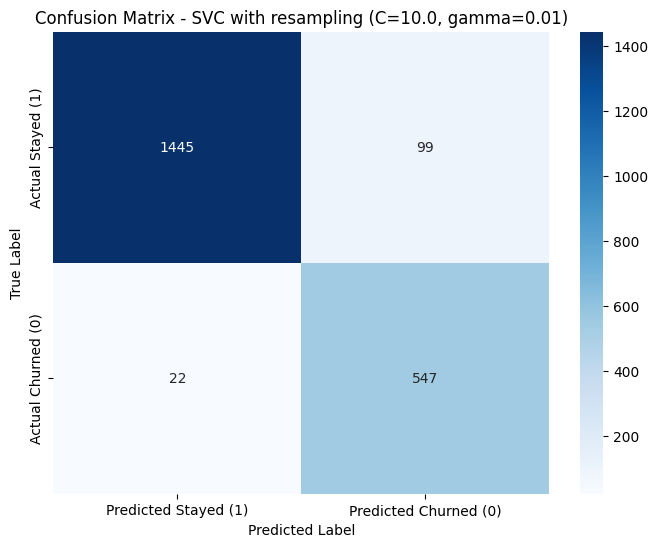

Результат классификации:
               precision    recall  f1-score   support

           0       0.85      0.96      0.90       569
           1       0.99      0.94      0.96      1544

    accuracy                           0.94      2113
   macro avg       0.92      0.95      0.93      2113
weighted avg       0.95      0.94      0.94      2113

Ошибка на обучающей выборке: 3.77%
Ошибка на тестовой выборке: 5.73%


In [53]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

svc = SVC(C=best_C, gamma=best_gamma).fit(X_train_resampled, y_train_resampled)
y1_pred = svc.predict(X_test)
err_train = np.mean(y_train_resampled != svc.predict(X_train_resampled))
err_test  = np.mean(y_test  != y1_pred)

# Матрица ошибок 
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y1_pred)

# Переворачиваем матрицу для того, чтобы она по структуре соответствовала общепринятой
cm_flipped = cm[::-1, ::-1]

sns.heatmap(cm_flipped, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Stayed (1)', 'Predicted Churned (0)'],
            yticklabels=['Actual Stayed (1)', 'Actual Churned (0)'])
plt.title(f'Confusion Matrix - SVC with resampling (C={best_C}, gamma={best_gamma})')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print(f'Результат классификации:\n {classification_report(y_test, y1_pred)}')
print(f'Ошибка на обучающей выборке: {round(100 * err_train, 2)}%')
print(f'Ошибка на тестовой выборке: {round(100 * err_test, 2)}%')

<p style="font-family: Times New Roman;"><b>11.3.</b> Градиентный бустинг.</p>

<p style="font-family: Times New Roman;">Подберём оптимальные значения параметров:</p>

In [54]:
param_grid = {
    'learning_rate': [0.1, 0.01, 0.001],
    'max_depth': [3, 4],
    'min_samples_split': [2, 4],
    'min_samples_leaf': [1, 2]
}
gbt = ensemble.GradientBoostingClassifier(n_estimators = 100)
grid_search = GridSearchCV(gbt, param_grid=param_grid, cv=5)
grid_search.fit(X_train_resampled, y_train_resampled)
best_params = grid_search.best_params_
print(f"Оптимальные параметры: {best_params}")

Оптимальные параметры: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2}


<p style="font-family: Times New Roman;">Протестируем модель с подобранными оптимальными параметрами на тестовых данных:</p>

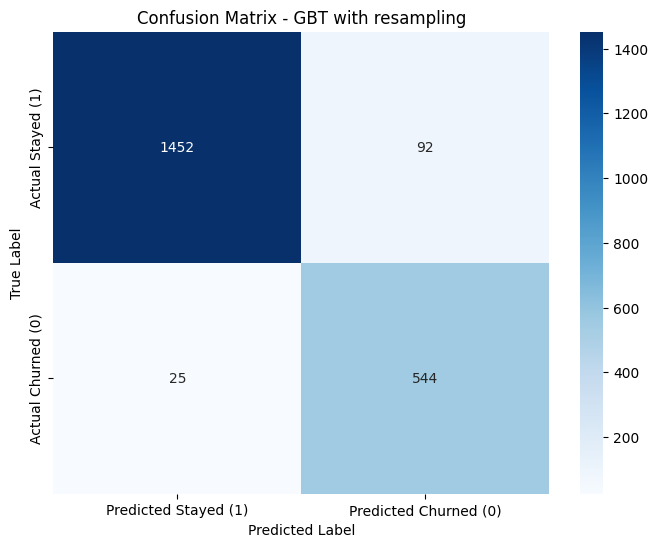

Результат классификации:
               precision    recall  f1-score   support

           0       0.86      0.96      0.90       569
           1       0.98      0.94      0.96      1544

    accuracy                           0.94      2113
   macro avg       0.92      0.95      0.93      2113
weighted avg       0.95      0.94      0.95      2113

Ошибка на обучающей выборке: 2.65%
Ошибка на тестовой выборке: 5.54%


In [55]:
from sklearn import ensemble
from sklearn.metrics import classification_report, confusion_matrix

gbt = ensemble.GradientBoostingClassifier(learning_rate=0.1, max_depth=3, min_samples_leaf=2, min_samples_split=2)
gbt.fit(X_train_resampled, y_train_resampled)
y1_pred = gbt.predict(X_test)
err_train = np.mean(y_train_resampled != gbt.predict(X_train_resampled))
err_test = np.mean(y_test != y1_pred)

# Матрица ошибок
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y1_pred)

# Переворачиваем матрицу для того, чтобы она по структуре соответствовала общепринятой
cm_flipped = cm[::-1, ::-1]

sns.heatmap(cm_flipped, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Stayed (1)', 'Predicted Churned (0)'],
            yticklabels=['Actual Stayed (1)', 'Actual Churned (0)'])
plt.title('Confusion Matrix - GBT with resampling')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print(f'Результат классификации:\n {classification_report(y_test, y1_pred)}')
print(f'Ошибка на обучающей выборке: {round(100 * err_train, 2)}%')
print(f'Ошибка на тестовой выборке: {round(100 * err_test, 2)}%')

<p style="font-family: Times New Roman;">Как мы можем заметить, после применения андерсэмплинга качество всех моделей снизилось, причём наиболее значительная деградация наблюдается у алгоритма K-ближайших соседей. На самом деле, это следствие сокращения объёма тренировочной выборки, которое приводит, как правило, к увеличению ошибки модели из-за недостаточного количества данных для обучения.</p>

<p style="font-family: Times New Roman;"><b>Пункт №12.</b> Исключение коррелированных переменных.</p>

<p style="font-family: Times New Roman;">На начальном этапе предобработки данных мной уже была проведена процедура удаления коррелированных переменных. Это решение основано на фундаментальном принципе машинного обучения: использование взаимосвязанных переменных приводит к мультиколлинеарности, которая проявляется в нестабильности коэффициентов модели, снижении её интерпретируемости и повышенной склонности к переобучению. По сути, коррелированные признаки дублируют информацию, не добавляя новой ценности, но при этом существенно ухудшают качество прогнозирования.</p>

<p style="font-family: Times New Roman;"><b>Пункт №13.</b> Общий вывод.</p>

<p style="font-family: Times New Roman;">Для решения задачи классификации использовались данные, содержащие 7043 объекта, каждый из которых описывается 50 признаками. Первоначальный анализ выявил проблему несбалансированности классов. На этапе предобработки данных был выполнен отбор признаков, в результате которого были исключены неинформативные и избыточные признаки, негативно влияющие на качество модели. Обработка пропущенных значений включала удаление одного столбца с дублирующей информацией и импутацию пропусков в другом столбце релевантными значениями.</p>

<p style="font-family: Times New Roman;">В ходе исследования были протестированы три алгоритма машинного обучения: метод K-ближайших соседей, метод опорных векторов и градиентный бустинг. Наилучшие результаты по всем метрикам продемонстрировала модель градиентного бустинга, которая показала свою устойчивость как на исходных, несбалансированных данных, так и после применения балансировки классов (в нашем случае — андерсэмплинг). Сравнительный анализ показал, что при работе с несбалансированными классами разница в эффективности между моделями незначительна (составляет несколько процентов). Однако после балансировки обучающей выборки работа модели K-ближайших соседей существенно ухудшилась. Все исследуемые модели продемонстрировали склонность к более точному предсказанию доминирующего класса, и эта тенденция сохранилась даже после выравнивания распределения классов.</p>

<p style="font-family: Times New Roman;">Проведённый поиск оптимальных гиперпараметров, несмотря на его высокую вычислительную стоимость, позволил значительно улучшить качество моделей.</p>

<p style="font-family: Times New Roman;">Домашняя работа №7. Выполнил: Сафаров Нурлан. ИИТММ. Программная инженерия. Магистратура. 1 курс. 3825М1ПР1.</p>

<p style="font-family: Times New Roman;"><b>Пункт №0.</b> Описание задачи.</p>

<p style="font-family: Times New Roman;">Используя те же самые данные, что и в домашней работе №4, требуется решить задачу кластеризации тремя методами: K-Means, DBSCAN, HC.

<p style="font-family: Times New Roman;">Условия:</p>
<p style="font-family: Times New Roman;">
• для визуализации результатов воспользуемся методом главных компонент;<br>
• в процессе обучения, конечно же, не будем использовать целевую метку;<br>
• после кластеризации сравним полученные кластеры с истинной меткой и сделаем выводы.<br>
</p>

<p style="font-family: Times New Roman;"><b>Пункт №1.</b> Подготовка данных для кластеризации.</p>

<p style="font-family: Times New Roman;">Кластеризация относится к задачам обучения без учителя, поэтому целевая переменная не должна использоваться при обучении моделей.

<p style="font-family: Times New Roman;">На предыдущих этапах уже были выполнены:</p>
<p style="font-family: Times New Roman;">
• обработка пропущенных значений (см. пункт №3 из 1-ой лаб. работы);<br>
• обработка (кодирование) категориальных признаков (см. пункт №4 из 1-ой лаб. работы);<br>
• нормализация количественных признаков (см. пункт №5 из 1-ой лаб. работы).<br>
</p>

<p style="font-family: Times New Roman;">Отделим признаки от целевой переменной, сохранив её исключительно для последующего анализа качества кластеризации:</p>

In [290]:
X = data.drop(['Churn Label'], axis=1)
y_true = data['Churn Label']

<p style="font-family: Times New Roman;"><b>Пункт №2.</b> Понижение размерности методом главных компонент (PCA).</p>

<p style="font-family: Times New Roman;">Исходное пространство признаков имеет высокую размерность (36 признаков), что:</p>
<p style="font-family: Times New Roman;">
• затрудняет визуальный анализ;<br>
• ухудшает интерпретируемость кластеров.<br>
</p>

<p style="font-family: Times New Roman;">Для решения этой проблемы применяется метод главных компонент:</p>

In [291]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=20)
X_pca = pca.fit_transform(X)

<p style="font-family: Times New Roman;">Вычислим долю объяснённой дисперсии и суммарную дисперсию:</p>

In [292]:
print(f'Доля объяснённой дисперсии: {pca.explained_variance_ratio_}')
print(f'Суммарная дисперсия: {pca.explained_variance_ratio_.sum():.2f}')

Доля объяснённой дисперсии: [0.19034031 0.12145837]
Суммарная дисперсия: 0.31


<p style="font-family: Times New Roman;">Видим, что метод главных компонент объясняет только 31% дисперсии данных. Итого — двух главных компонент недостаточно, чтобы хорошо представить структуру 36-мерного пространства.</p>

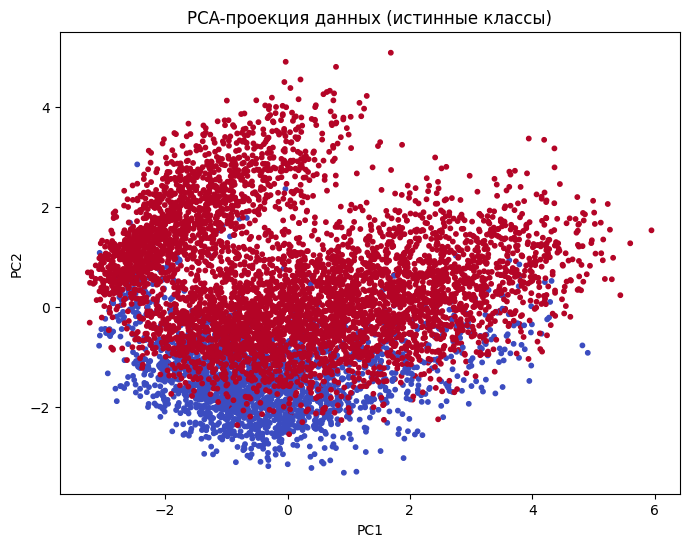

In [293]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='coolwarm', s=10)
plt.title('PCA-проекция данных (истинные классы)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


<p style="font-family: Times New Roman;">На графике наблюдается сильное перекрытие двух классов (отток и лояльные клиенты) в пространстве первых двух главных компонент: точки обоих классов равномерно перемешаны, образуя единое облако без четких кластерных структур или линейно разделимых областей Визуальное отсутствие разделимости напрямую коррелирует с метриками качества кластеризации, что указывает на фундаментальную сложность задачи: бинарное разделение на отток/неотток не соответствует естественной кластерной структуре данных в данном признаковом пространстве.</p>

<p style="font-family: Times New Roman;"><b>Пункт №3.</b> Кластеризация методом K-Means.</p>

<p style="font-family: Times New Roman;">В силу того, что в реальных данных присутствуют два класса, зададим:</p>


In [181]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=20)
kmeans_labels = kmeans.fit_predict(X)

<p style="font-family: Times New Roman;">Получим:</p>


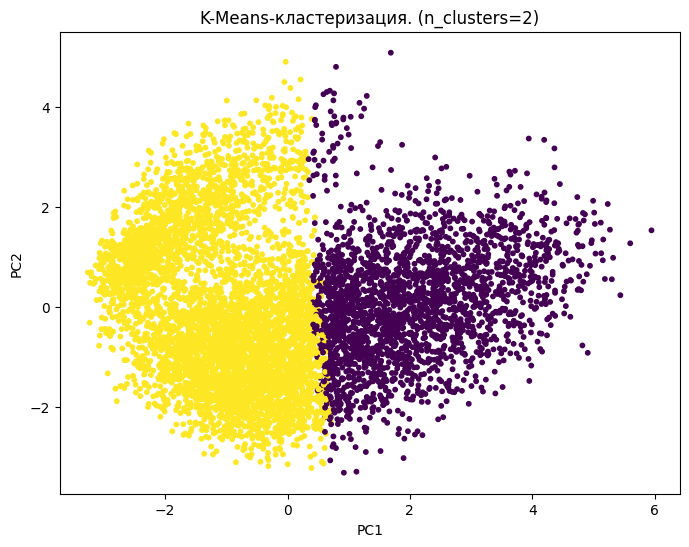

In [182]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', s=10)
plt.title('K-Means-кластеризация. (n_clusters=2)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


In [183]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

print('ARI:', adjusted_rand_score(y_true, kmeans_labels))
print('NMI:', normalized_mutual_info_score(y_true, kmeans_labels))

ARI: -0.0218305118612291
NMI: 0.02179543142687177


<p style="font-family: Times New Roman;">ARI = -0.022 и NMI = 0.022 демонстрируют крайне низкое качество кластеризации методом K-Means. Отрицательное значение ARI указывает, что полученное разбиение на кластеры даже хуже случайного угадывания — кластеры не соответствуют истинному распределению классов. Низкое значение NMI, близкое к нулю, подтверждает практически полное отсутствие взаимной информации между результатами кластеризации и реальными метками. Эти результаты свидетельствуют, что K-Means с двумя кластерами не смог выявить структуру, соответствующую бинарному разделению.</p>

<p style="font-family: Times New Roman;">Найдём оптимальное количество кластеров при помощи метода локтя:</p>

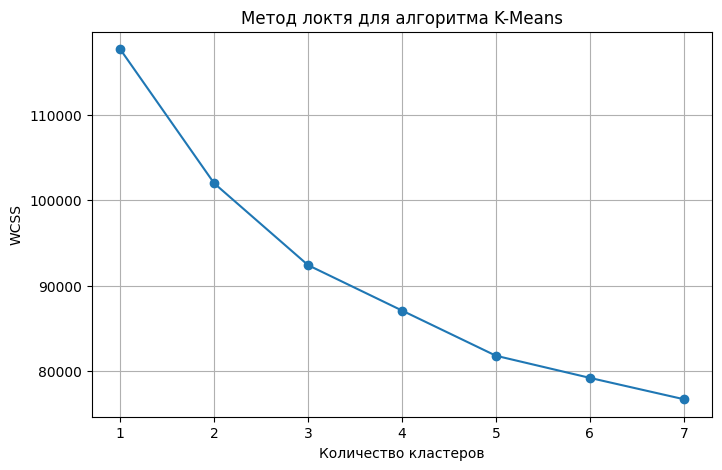

In [207]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
K_range = range(1, 8)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=20,
        n_init=10
    )
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker='o')
plt.xlabel('Количество кластеров')
plt.ylabel('WCSS')
plt.title('Метод локтя для алгоритма K-Means')
plt.grid(True)
plt.show()

<p style="font-family: Times New Roman;">На графике метода локтя для K-Means видно, что резкое уменьшение WCSS происходит до k = 3, после чего кривая начинает сглаживаться, и добавление новых кластеров почти не снижает сумму квадратов расстояний.</p>

<p style="font-family: Times New Roman;">Запустим алгоритм с найденным выше оптимальным значением количества кластеров:</p>


In [362]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=20)
kmeans_labels = kmeans.fit_predict(X)

<p style="font-family: Times New Roman;">Получим:</p>


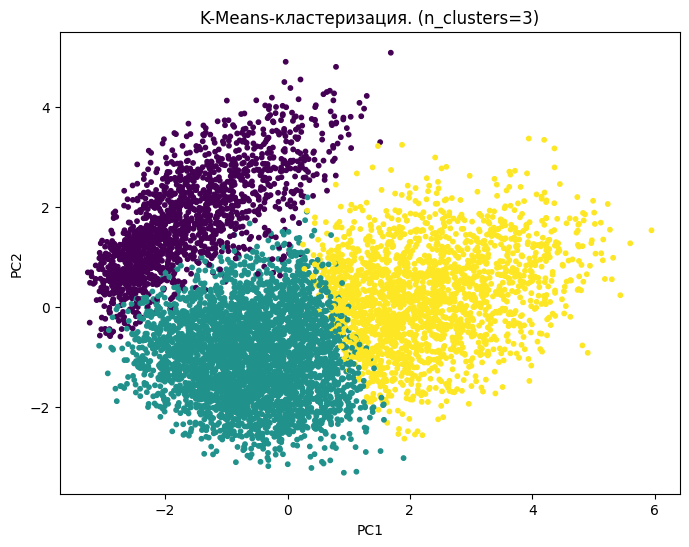

In [363]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', s=10)
plt.title('K-Means-кластеризация. (n_clusters=3)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

In [364]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

print('ARI:', adjusted_rand_score(y_true, kmeans_labels))
print('NMI:', normalized_mutual_info_score(y_true, kmeans_labels))

ARI: 0.012785079067418785
NMI: 0.09502699571987827


<p style="font-family: Times New Roman;">Полученные значения метрик ARI = 0.013 и NMI = 0.095 демонстрируют незначительное, но положительное улучшение качества кластеризации при переходе от 2 к 3 кластерам. Положительное значение ARI указывает, что разбиение теперь немного лучше случайного распределения, однако величина показателя остается крайне низкой (близкой к нулю), что свидетельствует о минимальном соответствии кластеров истинным меткам оттока. NMI = 0.095 также остается низким, подтверждая ограниченную информативность полученной кластеризации для предсказания оттока. Эти результаты позволяют сделать вывод: хотя увеличение числа кластеров до 3 улучшает внутреннюю структуру данных (что видно по методу локтя), полученные кластеры по-прежнему слабо коррелируют с целевой переменной оттока, что подчеркивает фундаментальное несоответствие между естественной сегментацией клиентов и бинарным делением на ушедших и оставшихся.</p>

<p style="font-family: Times New Roman;"><b>Пункт №4.</b> Кластеризация методом DBSCAN.</p>

<p style="font-family: Times New Roman;">Запустим метод с заданием определённых значений его параметров:</p>


In [365]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

<p style="font-family: Times New Roman;">Получим:</p>


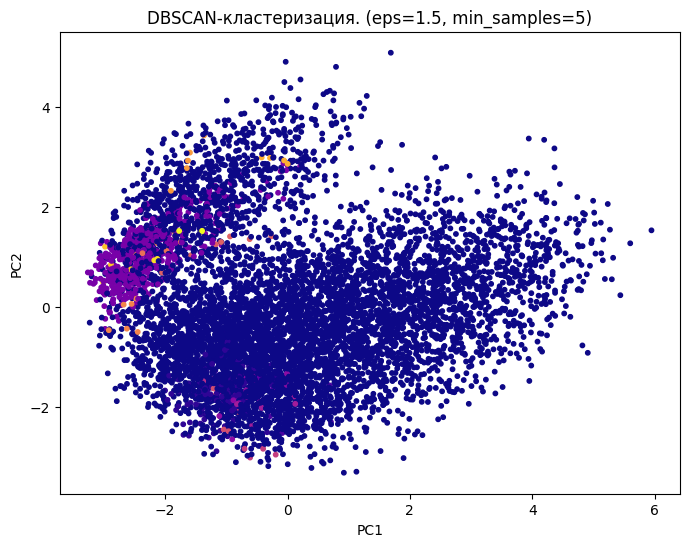

In [366]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='plasma', s=10)
plt.title('DBSCAN-кластеризация. (eps=1.5, min_samples=5)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


In [367]:
print('ARI:', adjusted_rand_score(y_true, dbscan_labels))
print('NMI:', normalized_mutual_info_score(y_true, dbscan_labels))

ARI: 0.01755409224933263
NMI: 0.0558182846750754


<p style="font-family: Times New Roman;">ARI = 0.018 и NMI = 0.056 — значения крайне низкие, практически на уровне случайного совпадения. Это подтверждает, что плотностные кластеры, найденные методом, практически не коррелируют с истинным разделением клиентов на ушедших и оставшихся.</p>

<p style="font-family: Times New Roman;">Как и в предыдущем случае, попробуем найти оптимальное значение первого параметра:</p>

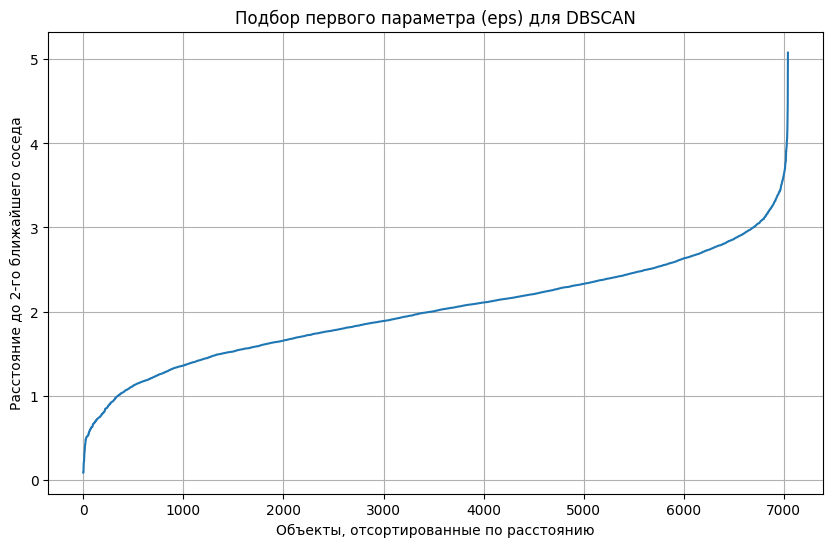

In [368]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

# Создаём объект ближайших соседей
neighbors = NearestNeighbors(n_neighbors=2)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)

# Берём расстояния до 2-го ближайшего соседа
distances = np.sort(distances[:, -1])

# Строим график
plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.xlabel("Объекты, отсортированные по расстоянию")
plt.ylabel(f"Расстояние до 2-го ближайшего соседа")
plt.title("Подбор первого параметра (eps) для DBSCAN")
plt.grid(True)
plt.show()


<p style="font-family: Times New Roman;"> На представленном графике резкий рост кривой начинается примерно на уровне 3–3.3 — в качестве оптимального значения первого параметра возьмём 3.15:</p>

In [369]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=3.15, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

<p style="font-family: Times New Roman;">Получим:</p>


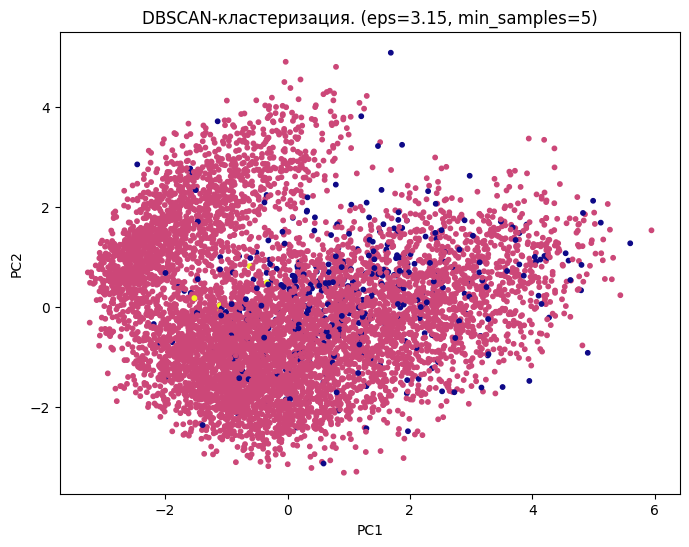

In [370]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='plasma', s=10)
plt.title('DBSCAN-кластеризация. (eps=3.15, min_samples=5)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

In [371]:
print('ARI:', adjusted_rand_score(y_true, dbscan_labels))
print('NMI:', normalized_mutual_info_score(y_true, dbscan_labels))

ARI: -0.0198727006598733
NMI: 0.004197460941579805


<p style="font-family: Times New Roman;">Как видно из вышеполученных значений метрик, подбор оптимального значения первного параметра по графику расстояний ухудшил согласованность кластеров с истинными метками, потому что алгоритм обнаруживает естественную группировку данных, основанную на плотности и сходстве множества признаков, которая принципиально не совпадает с бинарным разделением на тех, кто ушёл и тех, кто остался.</p>

<p style="font-family: Times New Roman;"><b>Пункт №5.</b> Иерархическая кластеризация.</p>

<p style="font-family: Times New Roman;">Запустим агломеративный метод (2 кластера):</p>


In [372]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=2, linkage='ward')
agg_labels = agg.fit_predict(X)

<p style="font-family: Times New Roman;">Получим:</p>


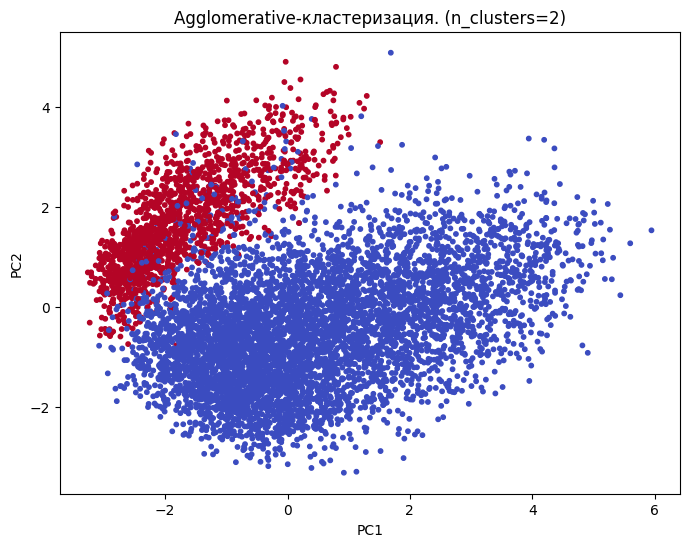

In [373]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels, cmap='coolwarm', s=10)
plt.title('Agglomerative-кластеризация. (n_clusters=2)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

In [374]:
print('ARI:', adjusted_rand_score(y_true, agg_labels))
print('NMI:', normalized_mutual_info_score(y_true, agg_labels))

ARI: -0.0668036236787562
NMI: 0.05283388480523563


<p style="font-family: Times New Roman;">ARI отрицательный, что означает, что кластеризация работает даже хуже, чем случайное распределение точек по кластерам. NMI близок к нулю, что подтверждает почти полное отсутствие взаимной информации между предсказанными кластерами и истинными метками. Результаты наглядно демонстрируют фундаментальное различие между задачами кластеризации (поиск естественной структуры в данных) и бинарной классификации (предсказание известных меток). Клиенты телеком-компании образуют сложные многомерные группы, которые не сводятся к простому разделению на тех, кто ушёл и тех, кто остался.</p>

<p style="font-family: Times New Roman;">Как правило, для иерархической кластеризации оптимальное число кластеров определяют по дендрограмме:</p>

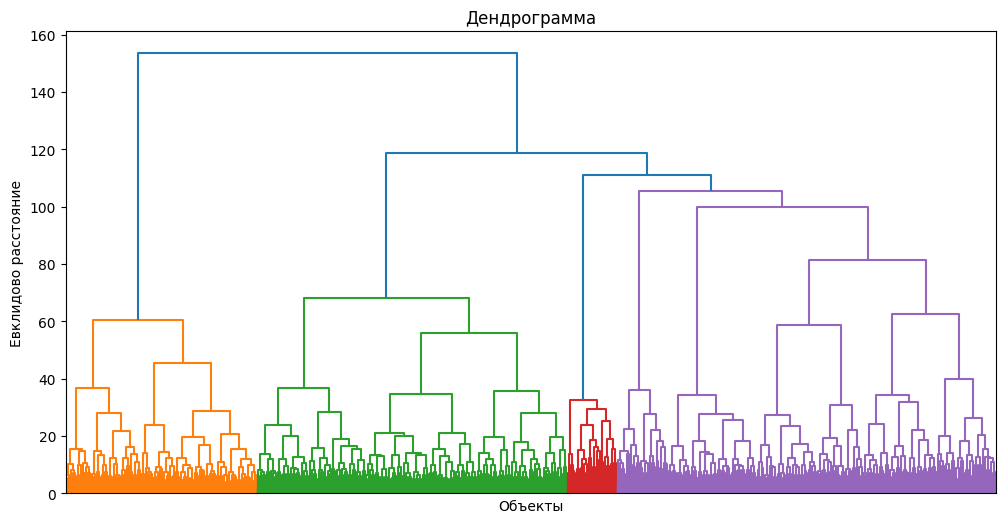

In [402]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
dendrogram = sch.dendrogram(
    sch.linkage(X, method='ward'),
    no_labels=True
)

plt.title('Дендрограмма')
plt.xlabel('Объекты')
plt.ylabel('Евклидово расстояние')
plt.show()


<p style="font-family: Times New Roman;">По построенной дендрограмме видно, что наиболее выраженный вертикальный разрыв наблюдается при переходе от трёх кластеров к двум: слияние трёх крупных ветвей в две происходит на существенно большем евклидовом расстоянии, чем все предыдущие объединения внутри этих ветвей. С учётом того, что для алгоритма K-Means оптимальное число кластеров также было определено как k = 3 методом локтя, выбор трёх кластеров является методически обоснованным и согласованным для разных подходов кластеризации, поэтому в качестве оптимального значения числа кластеров для иерархической кластеризации целесообразно выбрать 3 кластера:</p>

In [403]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
agg_labels = agg.fit_predict(X)

<p style="font-family: Times New Roman;">Получим:</p>


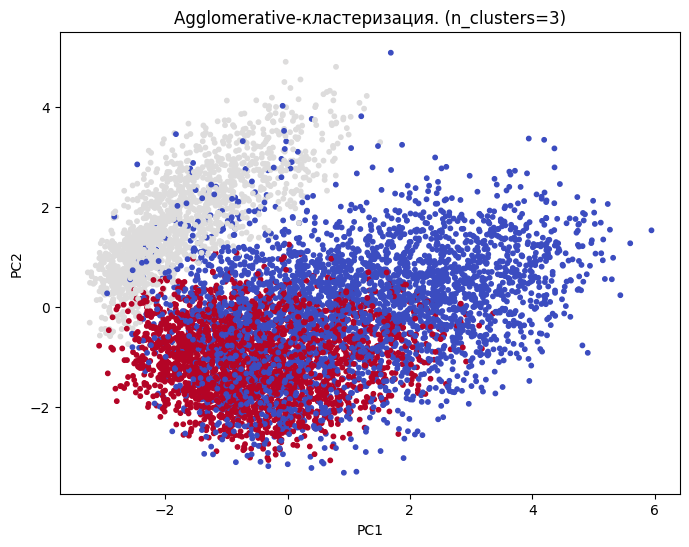

In [404]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels, cmap='coolwarm', s=10)
plt.title('Agglomerative-кластеризация. (n_clusters=3)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

In [405]:
print('ARI:', adjusted_rand_score(y_true, agg_labels))
print('NMI:', normalized_mutual_info_score(y_true, agg_labels))

ARI: 0.06101049177498183
NMI: 0.08504511204261965


<p style="font-family: Times New Roman;">Видим, что выбор числа кластеров, определённого на основе анализа дендрограммы (3 кластера), приводит к лучшему согласованию кластерной структуры с истинными метками по сравнению с разбиением на 2 кластера. В случае трёх кластеров значения метрик ARI = 0.061 и NMI = 0.085 остаются низкими, однако они выше, чем при двух кластерах, где ARI принимает отрицательное значение (–0.067), а NMI снижается до 0.053.</p>

<p style="font-family: Times New Roman;"><b>Пункт №6.</b> Общий вывод.</p>

<p style="font-family: Times New Roman;">В ходе данной лабораторной работы была решена задача кластеризации клиентов телекоммуникационной компании с использованием алгоритмов <b>K-Means</b>, <b>DBSCAN</b> и <b>иерархической кластеризации</b> без использования целевой переменной на этапе обучения. Применение метода главных компонент показало, что первые две компоненты объясняют лишь 31% дисперсии данных, а визуализация выявила сильное перекрытие классов оттока и неоттока, что указывает на отсутствие выраженной кластерной структуры, соответствующей бинарному разделению клиентов.</p>

<p style="font-family: Times New Roman;">Сравнительный анализ показал, что наиболее согласованные с истинными метками результаты продемонстрировала иерархическая кластеризация при числе кластеров, равном трём, выбранном на основе анализа дендрограммы и согласованном с методом локтя для K-Means. В этом случае значения ARI и NMI были максимальными среди всех рассмотренных подходов, хотя и оставались низкими в абсолютном выражении. Алгоритм K-Means также показал некоторое улучшение качества при увеличении числа кластеров до трёх, однако полученные кластеры по-прежнему слабо коррелировали с целевой переменной оттока.</p>

<p style="font-family: Times New Roman;">Метод DBSCAN во всех экспериментах продемонстрировал наихудшее соответствие истинным меткам. Более того, подбор оптимального значения первого параметра по графику расстояний до ближайших соседей привёл к ухудшению показателей качества, поскольку алгоритм стал выявлять плотностную структуру данных, не совпадающую с логикой формирования бинарного признака оттока. В целом полученные результаты подтверждают, что задача прогнозирования оттока клиентов не сводится к задаче кластеризации и требует применения методов обучения с учителем для получения высококачественных предсказаний.</p>